In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 121.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.31.1
    Uninstalling protobuf-6.31.1:
      Successfully uninstalled protobuf-6.31.1


In [ ]:
!pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 6.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time
import multiprocessing
import itertools
import warnings

from collections import Counter
from pandas.api.types import is_numeric_dtype

# Machine Learning Models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Metrics & Evaluation
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, precision_recall_curve,
    r2_score, mean_squared_error
)

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE, ADASYN

# Suppress warnings
warnings.filterwarnings("ignore")


In [ ]:
df = pd.read_csv("/content/Train.txt",sep=",",names=["duration","protocoltype","service","flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised","rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate",
"rerrorrate","srvrerrorrate","samesrvrate", "diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate","dsthostsamesrcportrate",
"dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate",
"dsthostrerrorrate","dsthostsrvrerrorrate","attack", "lastflag"])
df.head()

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
df.shape

(125973, 43)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   duration                125973 non-null  int64  
 1   protocoltype            125973 non-null  object 
 2   service                 125973 non-null  object 
 3   flag                    125973 non-null  object 
 4   srcbytes                125973 non-null  int64  
 5   dstbytes                125973 non-null  int64  
 6   land                    125973 non-null  int64  
 7   wrongfragment           125973 non-null  int64  
 8   urgent                  125973 non-null  int64  
 9   hot                     125973 non-null  int64  
 10  numfailedlogins         125973 non-null  int64  
 11  loggedin                125973 non-null  int64  
 12  numcompromised          125973 non-null  int64  
 13  rootshell               125973 non-null  int64  
 14  suattempted         

In [ ]:
df.describe()

,duration,srcbytes,dstbytes,land,wrongfragment,urgent,hot,numfailedlogins,loggedin,numcompromised,...,dsthostsrvcount,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,lastflag
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [ ]:
# Drop unnecessary columns
df.drop(['land','urgent','numfailedlogins','numoutboundcmds'],axis=1,inplace=True)

In [ ]:
df.isna().sum()

,0
duration,0
protocoltype,0
service,0
flag,0
srcbytes,0
dstbytes,0
wrongfragment,0
hot,0
loggedin,0
numcompromised,0


In [ ]:
df.select_dtypes(exclude=[np.number])

,protocoltype,service,flag,attack
0,tcp,ftp_data,SF,normal
1,udp,other,SF,normal
2,tcp,private,S0,neptune
3,tcp,http,SF,normal
4,tcp,http,SF,normal
...,...,...,...,...
125968,tcp,private,S0,neptune
125969,udp,private,SF,normal
125970,tcp,smtp,SF,normal
125971,tcp,klogin,S0,neptune


In [ ]:
df['attack'].loc[df['attack']!='normal']='attack'

In [ ]:
le=LabelEncoder()

In [ ]:
df['protocoltype']=le.fit_transform(df['protocoltype'])
df['service']=le.fit_transform(df['service'])
df['flag']=le.fit_transform(df['flag'])
df['attack']=le.fit_transform(df['attack'])

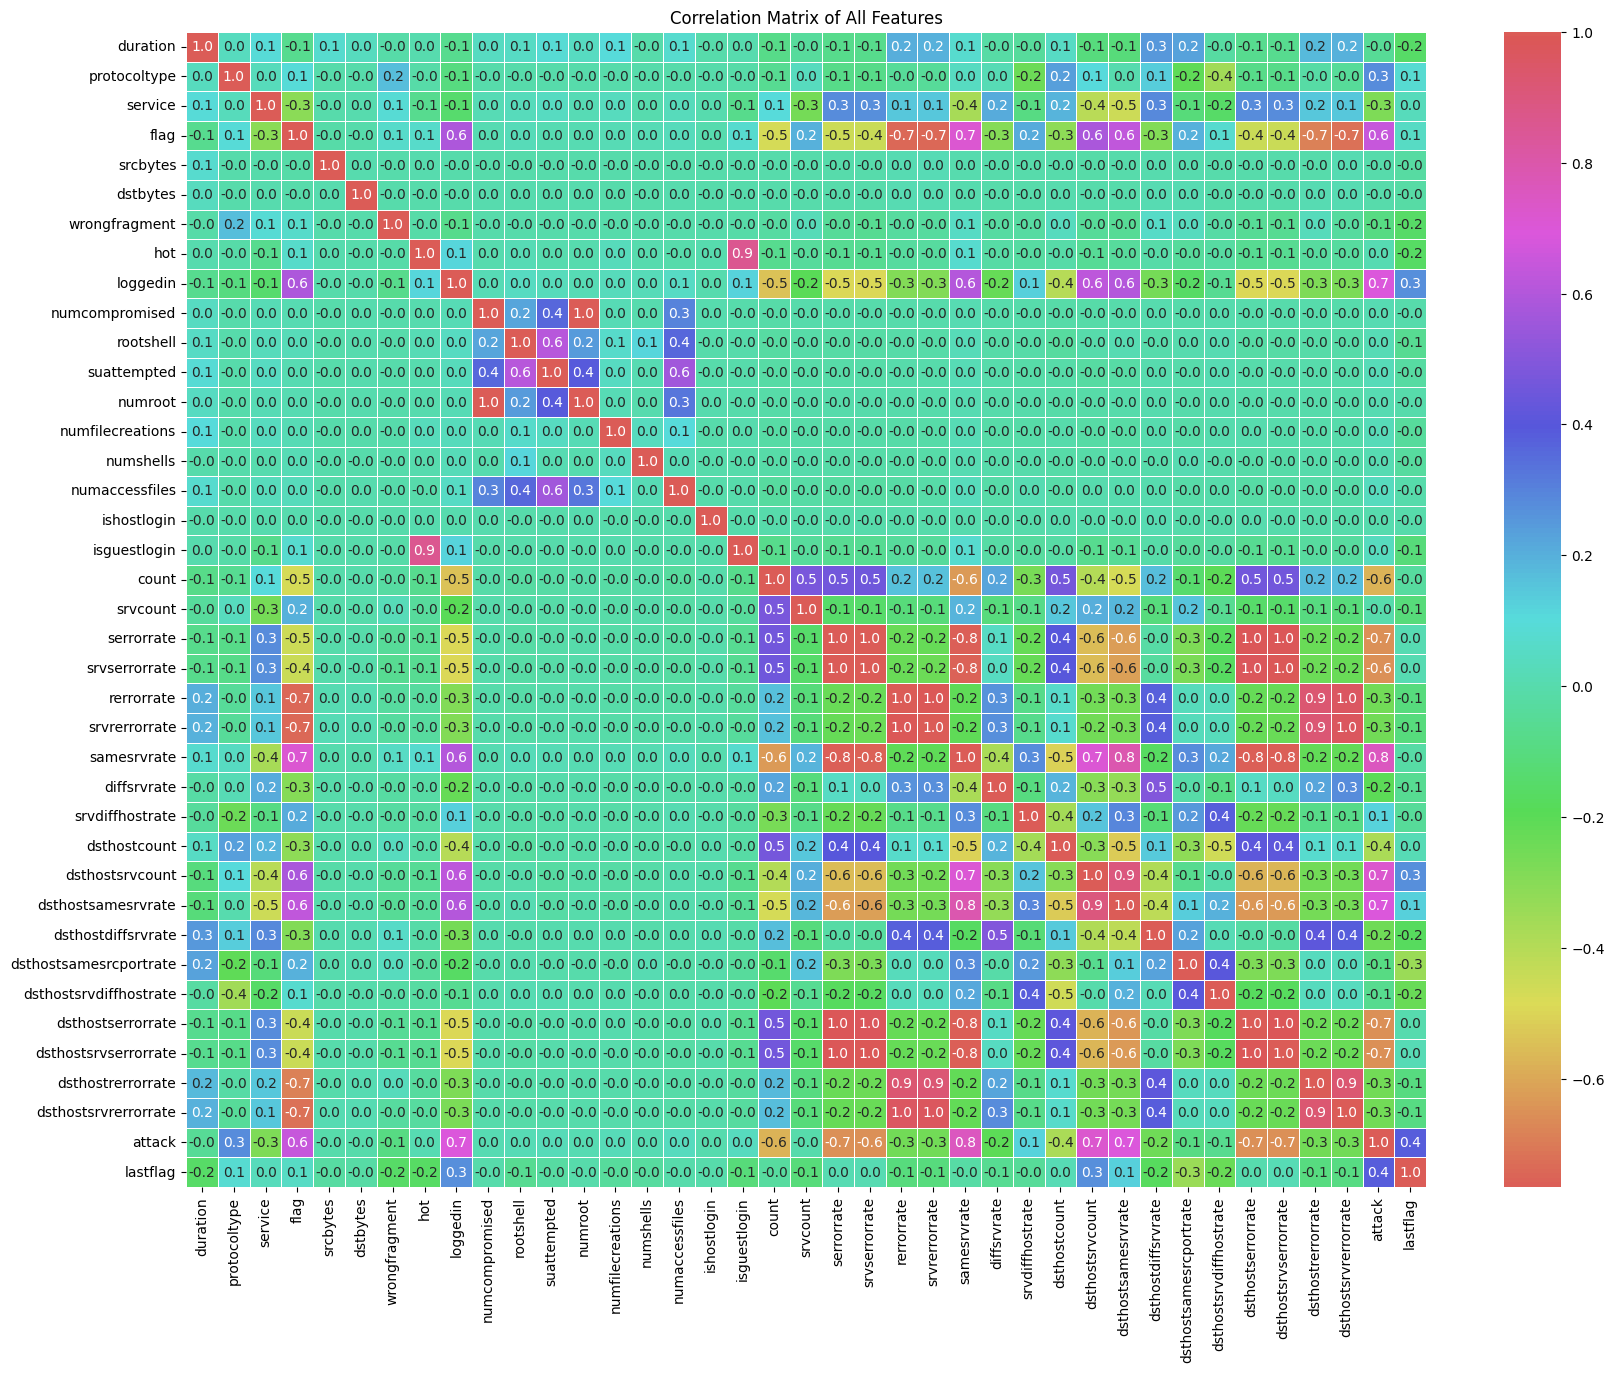

In [ ]:
# Calculate the correlation matrix
corr_matrix = df.corr(numeric_only=True)

cmap_husl = sns.hls_palette(as_cmap=True)
#cmap_husl = sns.husl_palette(as_cmap=True)

# Plot the correlation matrix with values using the Husl colormap
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap=cmap_husl, linewidths=0.5)
plt.title('Correlation Matrix of All Features')
plt.show()

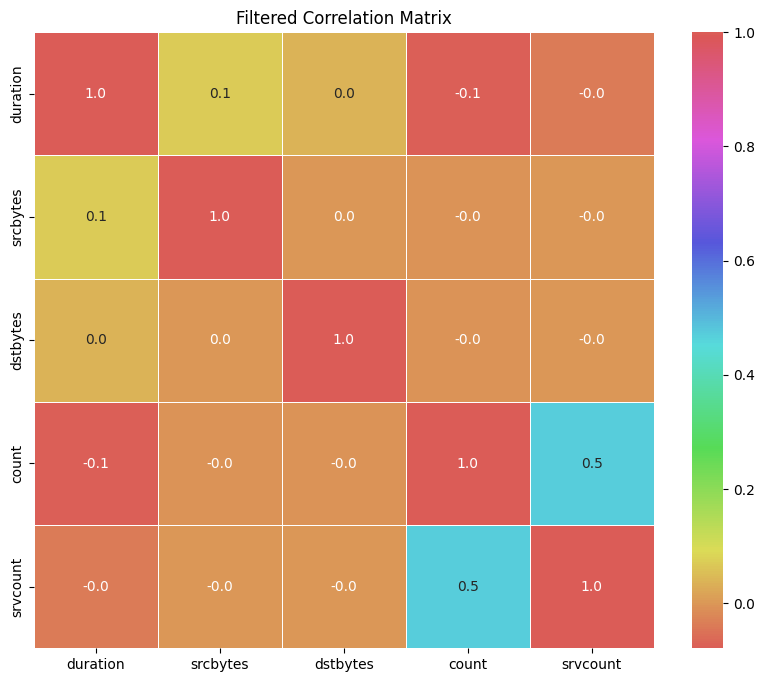

In [ ]:
# Filter the correlation matrix for specific features
selected_features = ['duration', 'srcbytes', 'dstbytes', 'count', 'srvcount']
filtered_corr_matrix = df[selected_features].corr()

# Plot the filtered correlation matrix
plt.figure(figsize=(10, 8))
cmap_husl = sns.hls_palette(as_cmap=True)
sns.heatmap(filtered_corr_matrix, annot=True, fmt=".1f", cmap= cmap_husl, linewidths=0.5)
plt.title('Filtered Correlation Matrix')
plt.show()

In [ ]:
X=df.drop(['attack'],axis=1)
y=df['attack']

In [ ]:
X

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsrvcount,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,lastflag
0,0,1,20,9,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,20
1,0,2,44,9,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,15
2,0,1,49,5,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,19
3,0,1,24,9,232,8153,0,0,1,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,21
4,0,1,24,9,199,420,0,0,1,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,25,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,20
125969,8,2,49,9,105,145,0,0,0,0,...,244,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,21
125970,0,1,54,9,2231,384,0,0,1,0,...,30,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,18
125971,0,1,30,5,0,0,0,0,0,0,...,8,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,20


In [ ]:
# Set the name of your target/output column
target_col = df['attack']

# Loop through each column and calculate correlation with target
print("Correlation of each feature with target:\n")
for col in df.columns:
    if col != target_col.name:  # Compare column name with the target column name
        correlation = df[[col, target_col.name]].corr().iloc[0, 1]
        if correlation>0.1:
          print(f"{col} : {correlation:.4f}")

Correlation of each feature with target:

protocoltype : 0.2814
flag : 0.6471
loggedin : 0.6902
samesrvrate : 0.7519
srvdiffhostrate : 0.1194
dsthostsrvcount : 0.7225
dsthostsamesrvrate : 0.6938
lastflag : 0.3797


In [ ]:
X=df[['protocoltype','flag','loggedin','samesrvrate','srvdiffhostrate','dsthostsrvcount','dsthostsamesrvrate','lastflag']]
y=df['attack']

In [ ]:
scaler = StandardScaler()
scaler.fit(X)
X_transformed = scaler.transform(X)

# Random forest

In [ ]:
# RF Model Creation
rf=RandomForestClassifier()
rf.fit(X_transformed,y)

RandomForestClassifier()

# Deecsion Tree

In [ ]:
# DT Model Creation
dt = DecisionTreeClassifier()
dt.fit(X_transformed, y)

DecisionTreeClassifier()

# Xg Boost

In [ ]:
# XGB Model Creation
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_transformed, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

# Using SVM

In [ ]:
# SVM Model Creation
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_transformed, y)

SVC(random_state=42)

# Logistic Regression

In [ ]:
# LR Model Creation
lr=LogisticRegression()
lr.fit(X_transformed,y)

LogisticRegression()

# KNN

In [ ]:
# KNN Model Creation
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_transformed, y)

KNeighborsClassifier()

# Model predictions

In [ ]:
# RF Model Predictions
rf_pred=rf.predict(X_transformed)

# DT Model Predictions
dt_pred=dt.predict(X_transformed)

# XGB Model Predictions
xgb_pred=xgb.predict(X_transformed)


# SVM Model Predictions
svm_pred=svm.predict(X_transformed)

# LR Model Predictions
lr_pred=lr.predict(X_transformed)

# KNN Model Predictions
knn_pred=knn.predict(X_transformed)

In [ ]:
def get_prediction_df(model_name, model, X, y):
    print(f"\n====== {model_name} Prediction DataFrame ======")
    y_pred = model.predict(X)
    pred_df = pd.DataFrame({'actual': y, 'pred': y_pred})
    print(pred_df.head())
    return pred_df


rf_df = get_prediction_df("Random Forest", rf, X_transformed, y)
dt_df  = get_prediction_df("Decision Tree", dt, X_transformed, y)
xgb_df = get_prediction_df("XGBoost", xgb, X_transformed, y)

svm_df = get_prediction_df("SVM", svm, X_transformed, y)
lr_df = get_prediction_df("Logistic Regression", lr, X_transformed, y)
knn_df = get_prediction_df("K-Nearest Neighbors", knn, X_transformed, y)


====== Random Forest Prediction DataFrame ======
   actual  pred
0       1     1
1       1     1
2       0     0
3       1     1
4       1     1

====== Decision Tree Prediction DataFrame ======
   actual  pred
0       1     1
1       1     1
2       0     0
3       1     1
4       1     1

====== XGBoost Prediction DataFrame ======
   actual  pred
0       1     1
1       1     0
2       0     0
3       1     1
4       1     1

====== SVM Prediction DataFrame ======
   actual  pred
0       1     1
1       1     0
2       0     0
3       1     1
4       1     1

====== Logistic Regression Prediction DataFrame ======
   actual  pred
0       1     1
1       1     0
2       0     0
3       1     1
4       1     1

====== K-Nearest Neighbors Prediction DataFrame ======
   actual  pred
0       1     1
1       1     0
2       0     0
3       1     1
4       1     1


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_ml_model(y, y_pred, model_name="Model"):
    print(f"\n{'='*30} {model_name} Training Evaluation {'='*30}\n")

    print("Accuracy:", accuracy_score(y, y_pred))
    print("\nClassification Report:")
    print(classification_report(y, y_pred))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y, y_pred))

    cm = confusion_matrix(y, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print("\nConfusion Matrix Parameters:")
    print(f"True Negatives (TN): {tn}")
    print(f"False Positives (FP): {fp}")
    print(f"False Negatives (FN): {fn}")
    print(f"True Positives (TP): {tp}")


evaluate_ml_model(y, rf_pred, "Random Forest")
evaluate_ml_model(y, dt_pred, "Decision Tree")
evaluate_ml_model(y, xgb_pred, "XGBoost")


evaluate_ml_model(y, svm_pred, "SVM")
evaluate_ml_model(y, lr_pred, "Logistic Regression")
evaluate_ml_model(y, knn_pred, "KNN")


============================== Random Forest Training Evaluation ==============================

Accuracy: 0.9991267970120581

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     58630
           1       1.00      1.00      1.00     67343

    accuracy                           1.00    125973
   macro avg       1.00      1.00      1.00    125973
weighted avg       1.00      1.00      1.00    125973


Confusion Matrix:
[[58589    41]
 [   69 67274]]

Confusion Matrix Parameters:
True Negatives (TN): 58589
False Positives (FP): 41
False Negatives (FN): 69
True Positives (TP): 67274

============================== Decision Tree Training Evaluation ==============================

Accuracy: 0.9991267970120581

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     58630
           1       1.00      1.00      1.00     67343

    accuracy           

In [ ]:
evaluate_ml_model(y, rf_pred, "Random Forest")
evaluate_ml_model(y, dt_pred, "Decision Tree")
evaluate_ml_model(y, xgb_pred, "XGBoost")
evaluate_ml_model(y, svm_pred, "SVM")
evaluate_ml_model(y, lr_pred, "Logistic Regression")
evaluate_ml_model(y, knn_pred, "KNN")



============================== Random Forest Training Evaluation ==============================

Accuracy: 0.9991267970120581

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     58630
           1       1.00      1.00      1.00     67343

    accuracy                           1.00    125973
   macro avg       1.00      1.00      1.00    125973
weighted avg       1.00      1.00      1.00    125973


Confusion Matrix:
[[58589    41]
 [   69 67274]]

Confusion Matrix Parameters:
True Negatives (TN): 58589
False Positives (FP): 41
False Negatives (FN): 69
True Positives (TP): 67274

============================== Decision Tree Training Evaluation ==============================

Accuracy: 0.9991267970120581

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     58630
           1       1.00      1.00      1.00     67343

    accuracy           

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a dictionary to hold all metrics
metrics_dict = {}

# Define models and their predictions
models = {
    "Random Forest": rf.predict(X_transformed),
    "Decision Tree": dt.predict(X_transformed),
    "XGBoost": xgb.predict(X_transformed),
    "SVM": svm.predict(X_transformed),
    "Logistic Regression": lr.predict(X_transformed),
    "KNN": knn.predict(X_transformed)
}

# Loop through each model and calculate metrics
for name, y_pred in models.items():
    report = classification_report(y, y_pred, output_dict=True, zero_division=0)
    metrics_dict[name] = {
        "accuracy": accuracy_score(y, y_pred),
        "precision": report["weighted avg"]["precision"],
        "recall": report["weighted avg"]["recall"],
        "f1-score": report["weighted avg"]["f1-score"]
    }

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics_dict).T.reset_index().rename(columns={"index": "Model"})


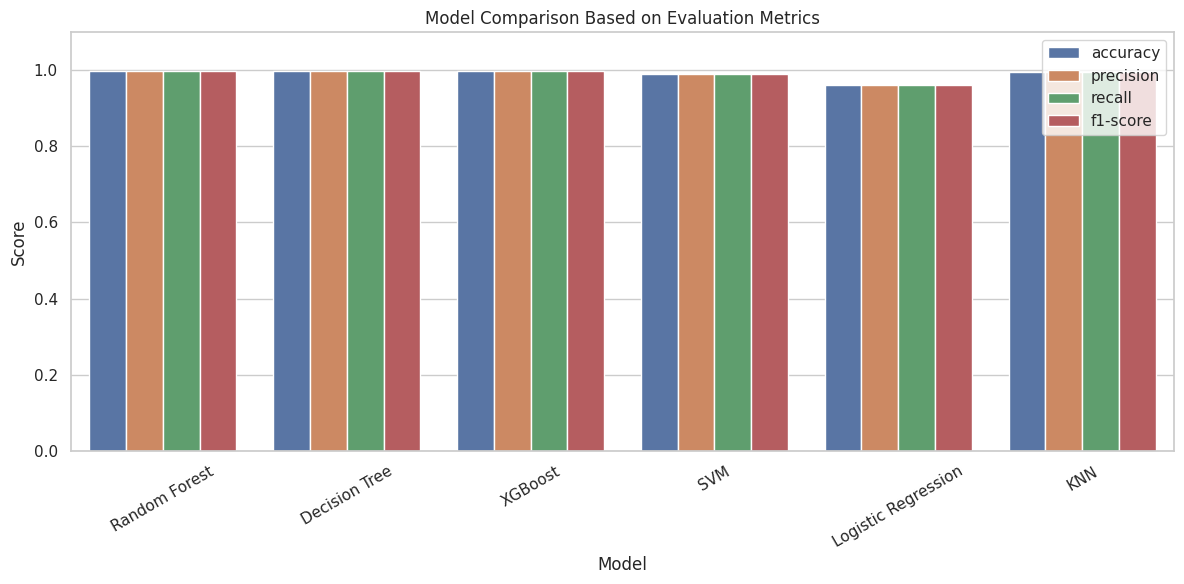

In [ ]:
# Set style
sns.set(style="whitegrid")

# Melt the DataFrame to long format for seaborn
metrics_long_df = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_long_df, x="Model", y="Score", hue="Metric")
plt.title("Model Comparison Based on Evaluation Metrics")
plt.ylim(0, 1.1)
plt.xticks(rotation=30)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


# Building  Deep Learning (DL) Models

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, LSTM, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Reshape data for DL models
X_reshaped_cnn = np.expand_dims(X_transformed, axis=-1)  # For CNN
X_reshaped_rnn = X_transformed.reshape(X_transformed.shape[0], 1, X_transformed.shape[1])  # For RNN

# Using CNN

In [ ]:
cnn_model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(X_transformed.shape[1], 1)),
    BatchNormalization(),
    Dropout(0.3),
    Conv1D(128, 3, activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer=Adam(0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

# Train CNN
cnn_history = cnn_model.fit(X_reshaped_cnn, y,
                          epochs=20,
                          batch_size=256,
                          validation_split=0.2,
                          callbacks=[EarlyStopping(patience=3)],
                          verbose=1)

Epoch 1/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9581 - loss: 0.0968 - val_accuracy: 0.9892 - val_loss: 0.0409
Epoch 2/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9869 - loss: 0.0357 - val_accuracy: 0.9902 - val_loss: 0.0266
Epoch 3/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9889 - loss: 0.0300 - val_accuracy: 0.9902 - val_loss: 0.0285
Epoch 4/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9896 - loss: 0.0287 - val_accuracy: 0.9916 - val_loss: 0.0235
Epoch 5/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9908 - loss: 0.0252 - val_accuracy: 0.9922 - val_loss: 0.0212
Epoch 6/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9908 - loss: 0.0246 - val_accuracy: 0.9919 - val_loss: 0.0195
Epoch 7/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9913 - loss: 0.0238 - val_accuracy: 0.9926 - val_loss: 0.0200
Epoch 8/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9917 - loss: 0.0225 - val_accu

# Using RNN

In [ ]:
rnn_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(1, X_transformed.shape[1])),
    Dropout(0.3),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer=Adam(0.0005),
                loss='binary_crossentropy',
                metrics=['accuracy'])

# Train RNN
rnn_history = rnn_model.fit(X_reshaped_rnn, y,
                          epochs=20,
                          batch_size=256,
                          validation_split=0.2,
                          callbacks=[EarlyStopping(patience=3)],
                          verbose=1)

Epoch 1/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9035 - loss: 0.4290 - val_accuracy: 0.9668 - val_loss: 0.0889
Epoch 2/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9679 - loss: 0.0829 - val_accuracy: 0.9765 - val_loss: 0.0594
Epoch 3/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9757 - loss: 0.0615 - val_accuracy: 0.9806 - val_loss: 0.0501
Epoch 4/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9795 - loss: 0.0523 - val_accuracy: 0.9815 - val_loss: 0.0467
Epoch 5/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9802 - loss: 0.0498 - val_accuracy: 0.9829 - val_loss: 0.0434
Epoch 6/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9806 - loss: 0.0464 - val_accuracy: 0.9836 - val_loss: 0.0404
Epoch 7/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9812 - loss: 0.0458 - val_accuracy: 0.9825 - val_loss: 0.0394
Epoch 8/20
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9822 - loss: 0.0433 - val_accuracy: 0.

# Using ANN

In [ ]:
ann_model = Sequential([
    Dense(256, activation='relu', input_dim=X_transformed.shape[1]),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

ann_model.compile(optimizer=Adam(0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

# Train ANN
ann_history = ann_model.fit(X_transformed, y,
                          epochs=30,
                          batch_size=256,
                          validation_split=0.2,
                          callbacks=[EarlyStopping(patience=5)],
                          verbose=1)


Epoch 1/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9549 - loss: 0.1373 - val_accuracy: 0.9836 - val_loss: 0.0416
Epoch 2/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9830 - loss: 0.0430 - val_accuracy: 0.9855 - val_loss: 0.0355
Epoch 3/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9853 - loss: 0.0377 - val_accuracy: 0.9885 - val_loss: 0.0310
Epoch 4/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9864 - loss: 0.0365 - val_accuracy: 0.9887 - val_loss: 0.0290
Epoch 5/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9884 - loss: 0.0324 - val_accuracy: 0.9898 - val_loss: 0.0282
Epoch 6/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9883 - loss: 0.0331 - val_accuracy: 0.9900 - val_loss: 0.0256
Epoch 7/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9889 - loss: 0.0300 - val_accuracy: 0.9902 - val_loss: 0.0247
Epoch 8/30
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9894 - loss: 0.0288 - val_accuracy: 0.

# Using Multi-Layer Perceptron

In [ ]:
mlp_model = Sequential([
    Dense(512, activation='relu', input_dim=X_transformed.shape[1]),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

mlp_model.compile(optimizer=Adam(0.0001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

# Train MLP
mlp_history = mlp_model.fit(X_transformed, y,
                          epochs=50,
                          batch_size=512,
                          validation_split=0.2,
                          callbacks=[EarlyStopping(patience=5)],
                          verbose=1)

Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.8794 - loss: 0.3822 - val_accuracy: 0.9664 - val_loss: 0.0994
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9656 - loss: 0.1010 - val_accuracy: 0.9744 - val_loss: 0.0680
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9721 - loss: 0.0775 - val_accuracy: 0.9782 - val_loss: 0.0568
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9758 - loss: 0.0648 - val_accuracy: 0.9807 - val_loss: 0.0511
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9788 - loss: 0.0577 - val_accuracy: 0.9822 - val_loss: 0.0473
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9803 - loss: 0.0530 - val_accuracy: 0.9829 - val_loss: 0.0447
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9802 - loss: 0.0510 - val_accuracy: 0.9831 - val_loss: 0.0431
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9825 - loss: 0.0471 - val_accu

# DL Evaluation on Training Data

In [ ]:
def evaluate_dl_model(model, X_data, model_type='ann'):
    if model_type == 'cnn':
        X_data = np.expand_dims(X_data, axis=-1)
    elif model_type == 'rnn':
        X_data = X_data.reshape(X_data.shape[0], 1, X_data.shape[1])

    preds = (model.predict(X_data) > 0.5).astype(int)

    print("Accuracy:", accuracy_score(y, preds))
    print("\nClassification Report:")
    print(classification_report(y, preds))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y, preds))

    cm = confusion_matrix(y, preds)
    tn, fp, fn, tp = cm.ravel()

    print("\nConfusion Matrix Parameters:")
    print(f"True Negatives (TN): {tn}")
    print(f"False Positives (FP): {fp}")
    print(f"False Negatives (FN): {fn}")
    print(f"True Positives (TP): {tp}")


print("\n=== CNN Training Evaluation ===")
evaluate_dl_model(cnn_model, X_transformed, 'cnn')

print("\n=== RNN Training Evaluation ===")
evaluate_dl_model(rnn_model, X_transformed, 'rnn')

print("\n=== ANN Training Evaluation ===")
evaluate_dl_model(ann_model, X_transformed)

print("\n=== MLP Training Evaluation ===")
evaluate_dl_model(mlp_model, X_transformed)


=== CNN Training Evaluation ===
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
Accuracy: 0.9936176799790432

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     58630
           1       1.00      0.99      0.99     67343

    accuracy                           0.99    125973
   macro avg       0.99      0.99      0.99    125973
weighted avg       0.99      0.99      0.99    125973


Confusion Matrix:
[[58363   267]
 [  537 66806]]

Confusion Matrix Parameters:
True Negatives (TN): 58363
False Positives (FP): 267
False Negatives (FN): 537
True Positives (TP): 66806

=== RNN Training Evaluation ===
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
Accuracy: 0.9859493701031173

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     58630
           1       0.99      0.99      0.99     67343

    accuracy                           0.99    125973
   macro av

3937/3937 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 3s 710us/step
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 4s 906us/step


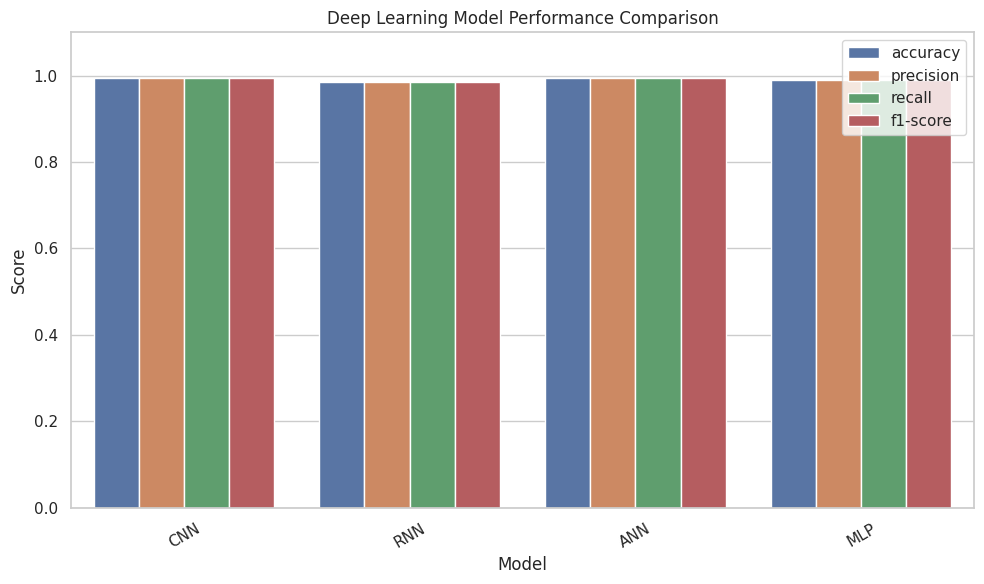

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report

# Evaluation function
def evaluate_dl_model(model, X_data, y_true, model_type='ann'):
    if model_type == 'cnn':
        X_data = np.expand_dims(X_data, axis=-1)
    elif model_type == 'rnn':
        X_data = X_data.reshape(X_data.shape[0], 1, X_data.shape[1])

    preds = (model.predict(X_data) > 0.5).astype(int)

    acc = accuracy_score(y_true, preds)
    report = classification_report(y_true, preds, output_dict=True, zero_division=0)

    return {
        "accuracy": acc,
        "precision": report["weighted avg"]["precision"],
        "recall": report["weighted avg"]["recall"],
        "f1-score": report["weighted avg"]["f1-score"]
    }

# Collect metrics for all models
results = {
    "CNN": evaluate_dl_model(cnn_model, X_transformed, y, 'cnn'),
    "RNN": evaluate_dl_model(rnn_model, X_transformed, y, 'rnn'),
    "ANN": evaluate_dl_model(ann_model, X_transformed, y),
    "MLP": evaluate_dl_model(mlp_model, X_transformed, y)
}

# Convert to DataFrame
df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})

# Melt for plotting
df_melted = df.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Plot the comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric")
plt.title("Deep Learning Model Performance Comparison")
plt.ylim(0, 1.1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.legend(loc="upper right")
plt.show()



# Load and Read the Test Data

In [ ]:
test_df = pd.read_csv("/content/Test.txt",sep=",",names=["duration","protocoltype","service","flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised","rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate",
"rerrorrate","srvrerrorrate","samesrvrate", "diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate","dsthostsamesrcportrate",
"dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate",
"dsthostrerrorrate","dsthostsrvrerrorrate","attack", "lastflag"])
test_df.head()

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 43 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   duration                22544 non-null  int64  
 1   protocoltype            22544 non-null  object 
 2   service                 22544 non-null  object 
 3   flag                    22544 non-null  object 
 4   srcbytes                22544 non-null  int64  
 5   dstbytes                22544 non-null  int64  
 6   land                    22544 non-null  int64  
 7   wrongfragment           22544 non-null  int64  
 8   urgent                  22544 non-null  int64  
 9   hot                     22544 non-null  int64  
 10  numfailedlogins         22544 non-null  int64  
 11  loggedin                22544 non-null  int64  
 12  numcompromised          22544 non-null  int64  
 13  rootshell               22544 non-null  int64  
 14  suattempted             22544 non-null

In [ ]:
test_df.shape

(22544, 43)

In [ ]:
test_df.select_dtypes(exclude=[np.number])

,protocoltype,service,flag,attack
0,tcp,private,REJ,neptune
1,tcp,private,REJ,neptune
2,tcp,ftp_data,SF,normal
3,icmp,eco_i,SF,saint
4,tcp,telnet,RSTO,mscan
...,...,...,...,...
22539,tcp,smtp,SF,normal
22540,tcp,http,SF,normal
22541,tcp,http,SF,back
22542,udp,domain_u,SF,normal


In [ ]:
test_df['attack'].loc[test_df['attack']!='normal']='attack'

In [ ]:
test_df['protocoltype']=le.fit_transform(test_df['protocoltype'])
test_df['service']=le.fit_transform(test_df['service'])
test_df['flag']=le.fit_transform(test_df['flag'])
test_df['attack']=le.fit_transform(test_df['attack'])

In [ ]:
# Drop unnecessary columns
test_df.drop(['land','urgent','numfailedlogins','numoutboundcmds'],axis=1,inplace=True)

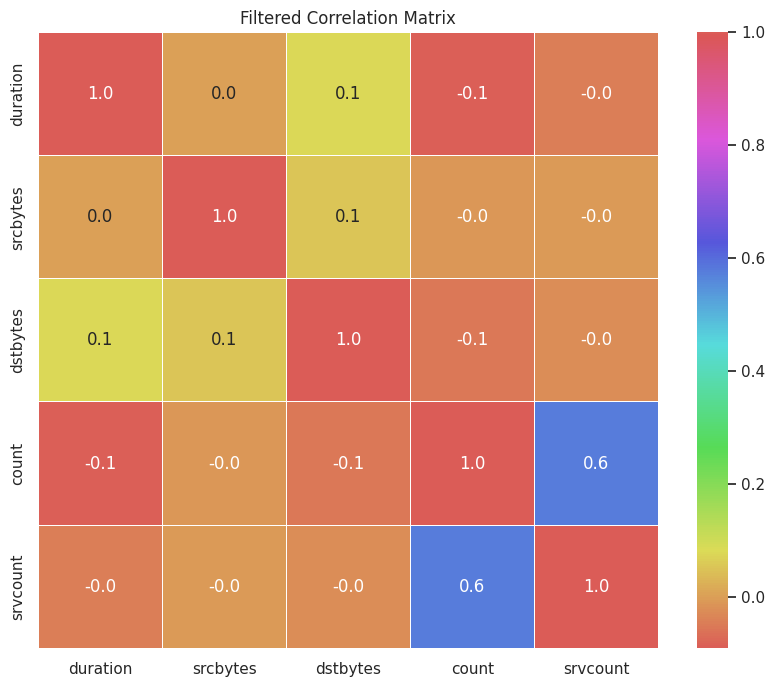

In [ ]:
# Filter the correlation matrix for specific features
selected_features = ['duration', 'srcbytes', 'dstbytes', 'count', 'srvcount']
filtered_corr_matrix = test_df[selected_features].corr()

# Plot the filtered correlation matrix
plt.figure(figsize=(10, 8))
cmap_husl = sns.hls_palette(as_cmap=True)
sns.heatmap(filtered_corr_matrix, annot=True, fmt=".1f", cmap= cmap_husl, linewidths=0.5)
plt.title('Filtered Correlation Matrix')
plt.show()

In [ ]:
X_test=test_df.drop(['attack'],axis=1)
y_test=test_df['attack']

In [ ]:
# Set the name of your target/output column
target_col = test_df['attack']

# Loop through each column and calculate correlation with target
print("Correlation of each feature with target:\n")
for col in test_df.columns:
    if col != target_col.name:  # Compare column name with the target column name
        correlation = test_df[[col, target_col.name]].corr().iloc[0, 1]
        if correlation>0.1:
          print(f"{col} : {correlation:.4f}")

Correlation of each feature with target:

protocoltype : 0.2264
flag : 0.5603
loggedin : 0.5512
samesrvrate : 0.5106
dsthostsrvcount : 0.5933
dsthostsamesrvrate : 0.5755
lastflag : 0.3959


In [ ]:
X_test = test_df[['protocoltype','flag','loggedin','samesrvrate','srvdiffhostrate','dsthostsrvcount','dsthostsamesrvrate','lastflag']]
X_test_transformed = scaler.transform(X_test)

# Implementing Classification Models for Test Data
# Model Selection

## 1. Random Forest
## 2. Decision Tree
## 3. Extreme Gradient Boosting (XGBoost)
## 4. Support Vector Machine (SVM)
## 5. Logistic Regression
## 6. K-Nearest Neighbors (KNN)
## 7. Convolutional Neural Networks (CNNs)
## 8. Recurrent Neural Networks (RNNs)
## 9. Artificial Neural Networks (ANNs)
## 10. Multilayer Perceptron (MLP)


In [ ]:
target_names=["attack","normal"]

Random Forest

============================== Random Forest Classifier ==============================
Accuracy:  0.8339691270404542
Precision:  0.7315691448083191
Recall:  0.9707548141283081
F1-score:  0.8343585431694472
Random Forest Classification Report of NAD:
               precision    recall  f1-score   support

      attack       0.97      0.73      0.83     12833
      normal       0.73      0.97      0.83      9711

    accuracy                           0.83     22544
   macro avg       0.85      0.85      0.83     22544
weighted avg       0.87      0.83      0.83     22544



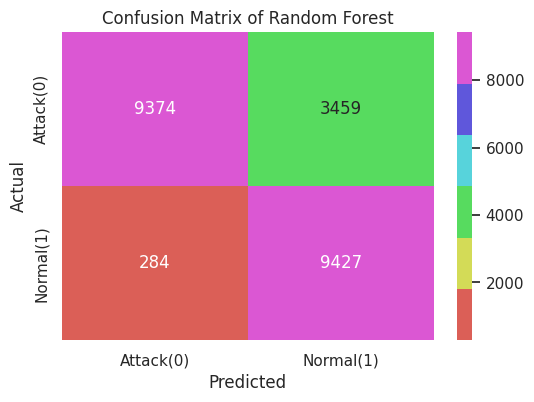


Confusion Matrix Parameters for Random Forest):
True Negatives (TN): 9374
False Positives (FP): 3459
False Negatives (FN): 284
True Positives (TP): 9427


In [ ]:
print('============================== Random Forest Classifier ==============================')

# Predictions
rf_pred=rf.predict(X_transformed)
rf_test_pred=rf.predict(X_test_transformed)

# Classification report & confusion matrix
rf_report = classification_report(y_test, rf_test_pred,target_names=target_names)
rf_cm = confusion_matrix(y_test, rf_test_pred)

# Evaluation Metrics
print("Accuracy: ", accuracy_score(y_test, rf_test_pred))
print("Precision: ", precision_score(y_test, rf_test_pred))
print("Recall: ", recall_score(y_test, rf_test_pred))
print("F1-score: ", f1_score(y_test, rf_test_pred))
print("Random Forest Classification Report of NAD:\n", rf_report)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cmap_husl = sns.hls_palette()
sns.heatmap(rf_cm, annot=True, fmt="d", cmap= cmap_husl,
            xticklabels=["Attack(0)","Normal(1)"],
            yticklabels=["Attack(0)","Normal(1)"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix of Random Forest")
plt.show()

# Print Confusion Matrix Components
tn, fp, fn, tp = confusion_matrix(y_test, rf_test_pred).ravel()
print('\nConfusion Matrix Parameters for Random Forest):')
print("True Negatives (TN):",tn)
print("False Positives (FP):",fp)
print("False Negatives (FN):",fn)
print("True Positives (TP):",tp)


Decision-Tree Classifier

============================== Decision-Tree Classifier ==============================
Accuracy:  0.8453690560681334
Precision:  0.7464956046566881
Recall:  0.9706518381217176
F1-score:  0.8439430566747247
Decision-Tree Classification Report of NAD:
               precision    recall  f1-score   support

      attack       0.97      0.75      0.85     12833
      normal       0.75      0.97      0.84      9711

    accuracy                           0.85     22544
   macro avg       0.86      0.86      0.85     22544
weighted avg       0.87      0.85      0.85     22544



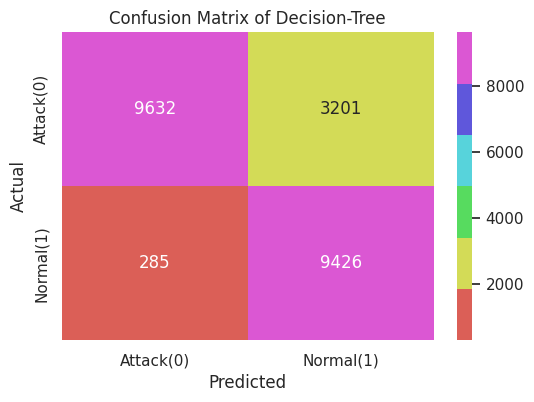


Confusion Matrix Parameters for Decision-Tree:
True Negatives (TN): 9632
False Positives (FP): 3201
False Negatives (FN): 285
True Positives (TP): 9426


In [ ]:
print('============================== Decision-Tree Classifier ==============================')

# Predictions
dt_pred = dt.predict(X_test_transformed)
dt_test_pred=dt.predict(X_test_transformed)

# Classification report & confusion matrix
dt_report = classification_report(y_test, dt_test_pred,target_names=target_names)
dt_cm = confusion_matrix(y_test, dt_test_pred)

# Evaluation Metrics
print("Accuracy: ", accuracy_score(y_test,dt_test_pred))
print("Precision: ", precision_score(y_test,dt_test_pred))
print("Recall: ", recall_score(y_test, dt_test_pred))
print("F1-score: ", f1_score(y_test, dt_test_pred))
print("Decision-Tree Classification Report of NAD:\n", dt_report)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cmap_husl = sns.hls_palette()
sns.heatmap(dt_cm, annot=True, fmt="d", cmap= cmap_husl,
            xticklabels=["Attack(0)","Normal(1)"],
            yticklabels=["Attack(0)","Normal(1)"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix of Decision-Tree")
plt.show()

# Print Confusion Matrix Components
tn, fp, fn, tp = confusion_matrix(y_test, dt_test_pred).ravel()
print('\nConfusion Matrix Parameters for Decision-Tree:')
print("True Negatives (TN):",tn)
print("False Positives (FP):",fp)
print("False Negatives (FN):",fn)
print("True Positives (TP):",tp)

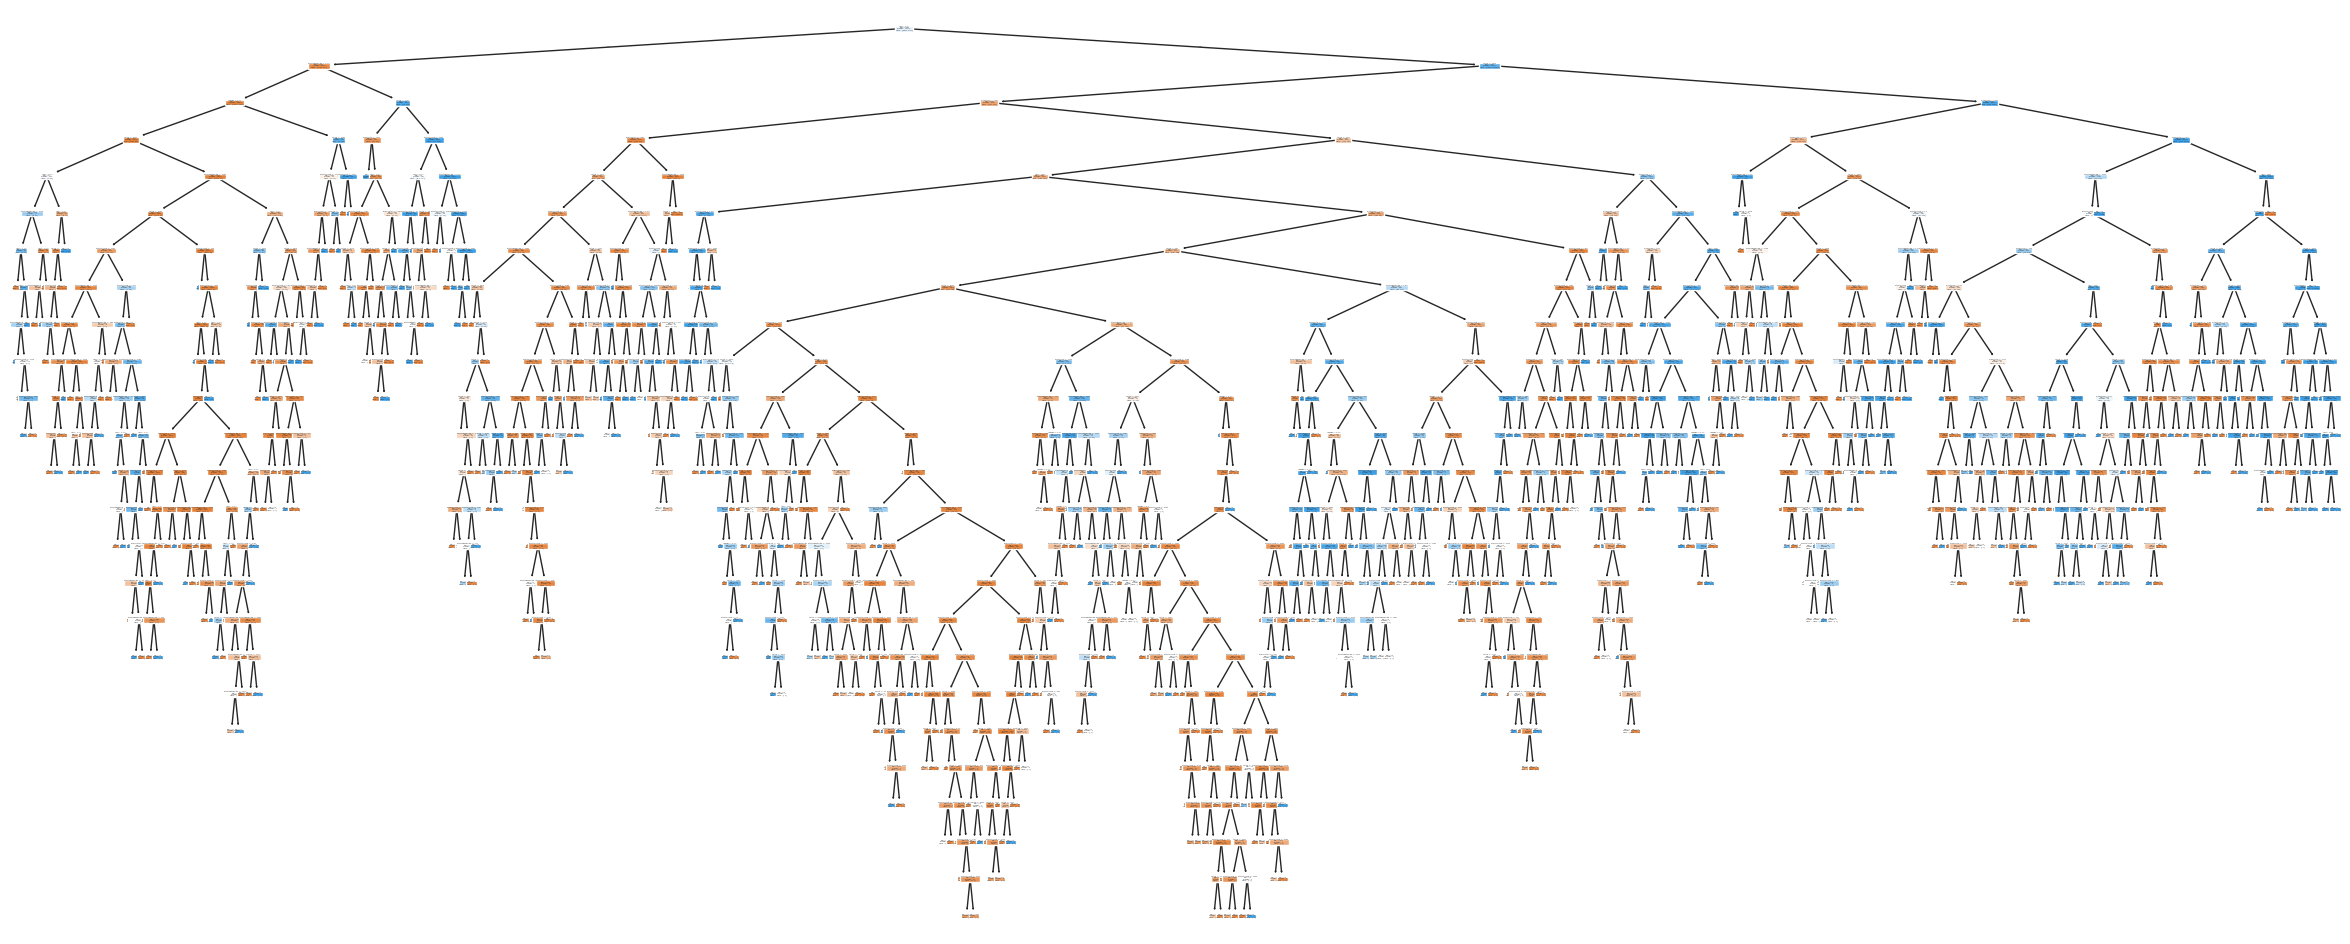

In [ ]:
# Decision Tree Visualization
from sklearn.tree import plot_tree

fig = plt.figure(figsize=(30, 12))
plot_tree(dt, filled=True, feature_names=X_test.columns)
plt.show()

Extreme Gradient Boosting

============================== XGBoost Classifier ==============================
Accuracy:  0.8289567068843151
Precision:  0.725452445128995
Recall:  0.9700339820821748
F1-score:  0.8301022206556221
XGBoost Classification Report of NAD:
               precision    recall  f1-score   support

      attack       0.97      0.72      0.83     12833
      normal       0.73      0.97      0.83      9711

    accuracy                           0.83     22544
   macro avg       0.85      0.85      0.83     22544
weighted avg       0.86      0.83      0.83     22544



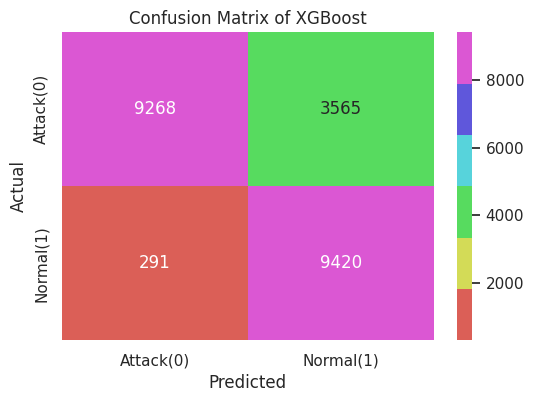


Confusion Matrix Parameters for XGBoost:
True Negatives (TN): 9268
False Positives (FP): 3565
False Negatives (FN): 291
True Positives (TP): 9420


In [ ]:
print('============================== XGBoost Classifier ==============================')

# Predictions
xgb_pred=xgb.predict(X_transformed)
xgb_test_pred=xgb.predict(X_test_transformed)

# Classification report & confusion matrix
xgb_report = classification_report(y_test, xgb_test_pred,target_names=target_names)
xgb_cm = confusion_matrix(y_test, xgb_test_pred)

# Evaluation Metrics
print("Accuracy: ", accuracy_score(y_test,xgb_test_pred))
print("Precision: ", precision_score(y_test,xgb_test_pred))
print("Recall: ", recall_score(y_test, xgb_test_pred))
print("F1-score: ", f1_score(y_test, xgb_test_pred))
print("XGBoost Classification Report of NAD:\n", xgb_report)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cmap_husl = sns.hls_palette()
sns.heatmap(xgb_cm, annot=True, fmt="d", cmap= cmap_husl,
            xticklabels=["Attack(0)","Normal(1)"],
            yticklabels=["Attack(0)","Normal(1)"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix of XGBoost")
plt.show()

# Print Confusion Matrix Components
tn, fp, fn, tp = confusion_matrix(y_test, xgb_test_pred).ravel()
print('\nConfusion Matrix Parameters for XGBoost:')
print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

Support Vector Machine (SVM)

============================== Support Vector Machine (SVM) ==============================
Accuracy:  0.8380500354861604
Precision:  0.7398670044331855
Recall:  0.9624137575944804
F1-score:  0.8365931164122992
SVM Classification Report of NAD:
               precision    recall  f1-score   support

      attack       0.96      0.74      0.84     12833
      normal       0.74      0.96      0.84      9711

    accuracy                           0.84     22544
   macro avg       0.85      0.85      0.84     22544
weighted avg       0.87      0.84      0.84     22544



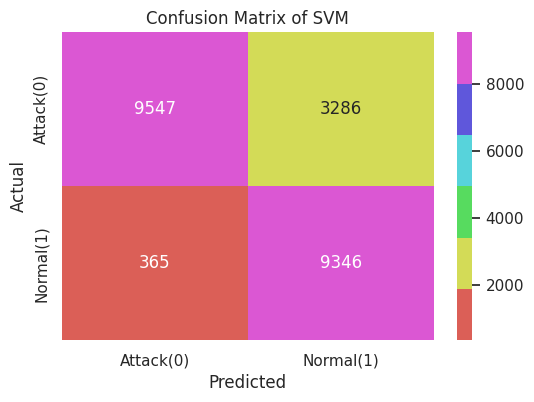


Confusion Matrix Parameters for Support Vector Machine (SVM):
True Negatives (TN): 9547
False Positives (FP): 3286
False Negatives (FN): 365
True Positives (TP): 9346


In [ ]:
print('============================== Support Vector Machine (SVM) ==============================')

# Predictions
svm_pred=svm.predict(X_transformed)
svm_test_pred=svm.predict(X_test_transformed)

# Classification report & confusion matrix
svm_report = classification_report(y_test, svm_test_pred,target_names=target_names)
svm_cm = confusion_matrix(y_test, svm_test_pred)

# Evaluation Metrics
print("Accuracy: ", accuracy_score(y_test,svm_test_pred))
print("Precision: ", precision_score(y_test,svm_test_pred))
print("Recall: ", recall_score(y_test, svm_test_pred))
print("F1-score: ", f1_score(y_test, svm_test_pred))
print("SVM Classification Report of NAD:\n", svm_report)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cmap_husl = sns.hls_palette()
sns.heatmap(svm_cm, annot=True, fmt="d", cmap= cmap_husl,
            xticklabels=["Attack(0)","Normal(1)"],
            yticklabels=["Attack(0)","Normal(1)"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix of SVM")
plt.show()

# Print Confusion Matrix Components
tn, fp, fn, tp = confusion_matrix(y_test, svm_test_pred).ravel()
print('\nConfusion Matrix Parameters for Support Vector Machine (SVM):')
print("True Negatives (TN):",tn)
print("False Positives (FP):",fp)
print("False Negatives (FN):",fn)
print("True Positives (TP):",tp)

Logistic Regression

============================== Logistic Regression ==============================
Accuracy:  0.8685681334279631
Precision:  0.7871000680735194
Recall:  0.9525280609617959
F1-score:  0.8619484694590691
Logistic Regression Classification Report of NAD:
               precision    recall  f1-score   support

      attack       0.96      0.81      0.87     12833
      normal       0.79      0.95      0.86      9711

    accuracy                           0.87     22544
   macro avg       0.87      0.88      0.87     22544
weighted avg       0.88      0.87      0.87     22544



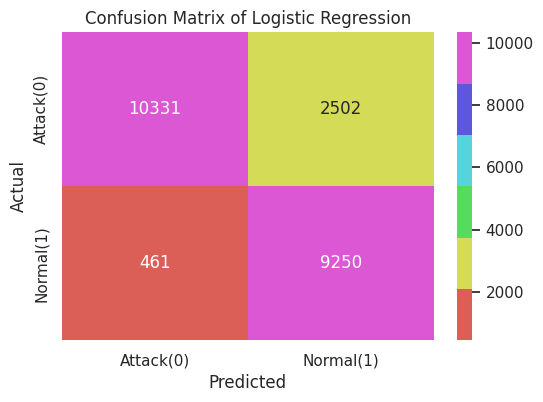


Confusion Matrix Parameters for Logistic Regression:
True Negatives (TN): 10331
False Positives (FP): 2502
False Negatives (FN): 461
True Positives (TP): 9250


In [ ]:
print('============================== Logistic Regression ==============================')

# Predictions
lr_pred=lr.predict(X_transformed)
lr_test_pred=lr.predict(X_test_transformed)

# Classification report & confusion matrix
lr_report = classification_report(y_test, lr_test_pred,target_names=target_names)
lr_cm = confusion_matrix(y_test, lr_test_pred)

# Evaluation Metrics
print("Accuracy: ", accuracy_score(y_test,lr_test_pred))
print("Precision: ", precision_score(y_test,lr_test_pred))
print("Recall: ", recall_score(y_test, lr_test_pred))
print("F1-score: ", f1_score(y_test, lr_test_pred))
print("Logistic Regression Classification Report of NAD:\n", lr_report)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cmap_husl = sns.hls_palette()
sns.heatmap(lr_cm, annot=True, fmt="d", cmap= cmap_husl,
            xticklabels=["Attack(0)","Normal(1)"],
            yticklabels=["Attack(0)","Normal(1)"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix of Logistic Regression")
plt.show()

# Print Confusion Matrix Components
tn, fp, fn, tp = confusion_matrix(y_test, lr_test_pred).ravel()
print('\nConfusion Matrix Parameters for Logistic Regression:')
print("True Negatives (TN):",tn)
print("False Positives (FP):",fp)
print("False Negatives (FN):",fn)
print("True Positives (TP):",tp)

K-Nearest Neighbors (KNN)

============================== K-Nearest Neighbors Classifier ==============================
Accuracy:  0.8508250532292406
Precision:  0.7541232986389111
Recall:  0.9699310060755844
F1-score:  0.8485203369217603
KNN Classification Report of NAD:
               precision    recall  f1-score   support

      attack       0.97      0.76      0.85     12833
      normal       0.75      0.97      0.85      9711

    accuracy                           0.85     22544
   macro avg       0.86      0.87      0.85     22544
weighted avg       0.88      0.85      0.85     22544



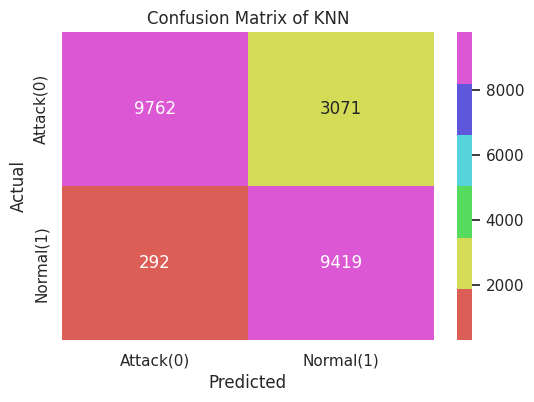


Confusion Matrix Parameters for K-Nearest Neighbors (KNN):
True Negatives (TN): 9762
False Positives (FP): 3071
False Negatives (FN): 292
True Positives (TP): 9419


In [ ]:
print('============================== K-Nearest Neighbors Classifier ==============================')

# Predictions
knn_pred = knn.predict(X_transformed)
knn_test_pred=knn.predict(X_test_transformed)

# Classification report & confusion matrix
knn_report = classification_report(y_test, knn_test_pred,target_names=target_names)
knn_cm = confusion_matrix(y_test, knn_test_pred)

# Evaluation Metrics
print("Accuracy: ", accuracy_score(y_test,knn_test_pred))
print("Precision: ", precision_score(y_test,knn_test_pred))
print("Recall: ", recall_score(y_test, knn_test_pred))
print("F1-score: ", f1_score(y_test, knn_test_pred))
print("KNN Classification Report of NAD:\n", knn_report)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cmap_husl = sns.hls_palette()
sns.heatmap(knn_cm, annot=True, fmt="d", cmap= cmap_husl,
            xticklabels=["Attack(0)","Normal(1)"],
            yticklabels=["Attack(0)","Normal(1)"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix of KNN")
plt.show()

# Print Confusion Matrix Components
tn, fp, fn, tp = confusion_matrix(y_test, knn_test_pred).ravel()
print('\nConfusion Matrix Parameters for K-Nearest Neighbors (KNN):')
print("True Negatives (TN):",tn)
print("False Positives (FP):",fp)
print("False Negatives (FN):",fn)
print("True Positives (TP):",tp)

Convolutional Neural Networks (CNNs)


============================== Convolutional Neural Network (CNN) ==============================
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Accuracy:  0.8429737402413059
Precision:  0.7435087996211822
Recall:  0.9701369580887653
F1-score:  0.841837190599589
CNN Classification Report of NAD:
               precision    recall  f1-score   support

      attack       0.97      0.75      0.84     12833
      normal       0.74      0.97      0.84      9711

    accuracy                           0.84     22544
   macro avg       0.86      0.86      0.84     22544
weighted avg       0.87      0.84      0.84     22544



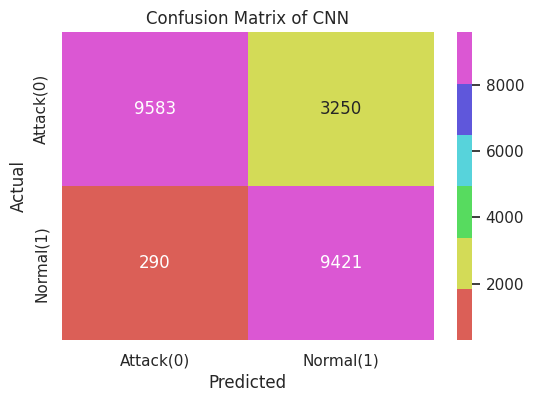


Confusion Matrix Parameters for Convolutional Neural Network (CNN):
True Negatives (TN): 9583
False Positives (FP): 3250
False Negatives (FN): 290
True Positives (TP): 9421


In [ ]:
print('\n============================== Convolutional Neural Network (CNN) ==============================')

# Transform and reshape test data
X_test_transformed = scaler.transform(X_test)
X_test_cnn = np.expand_dims(X_test_transformed, axis=-1)

# Predictions
cnn_test_pred = (cnn_model.predict(X_test_cnn) > 0.5).astype(int)

# Classification report & confusion matrix
cnn_report = classification_report(y_test, cnn_test_pred, target_names=target_names)
cnn_cm = confusion_matrix(y_test, cnn_test_pred)

# Evaluation Metrics
print("Accuracy: ", accuracy_score(y_test,cnn_test_pred))
print("Precision: ", precision_score(y_test,cnn_test_pred))
print("Recall: ", recall_score(y_test, cnn_test_pred))
print("F1-score: ", f1_score(y_test, cnn_test_pred))
print("CNN Classification Report of NAD:\n", cnn_report)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cmap_husl = sns.hls_palette()
sns.heatmap(cnn_cm, annot=True, fmt="d", cmap= cmap_husl,
            xticklabels=["Attack(0)","Normal(1)"],
            yticklabels=["Attack(0)","Normal(1)"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix of CNN")
plt.show()

# Print Confusion Matrix Components
tn, fp, fn, tp = confusion_matrix(y_test, cnn_test_pred).ravel()
print('\nConfusion Matrix Parameters for Convolutional Neural Network (CNN):')
print("True Negatives (TN):",tn)
print("False Positives (FP):",fp)
print("False Negatives (FN):",fn)
print("True Positives (TP):",tp)

Recurrent Neural Networks (RNNs)


============================== Recurrent Neural Network (RNN) ==============================
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Accuracy:  0.8541962384669979
Precision:  0.7635811587067126
Recall:  0.9581917413242714
F1-score:  0.8498881125268302
CNN Classification Report of NAD:
               precision    recall  f1-score   support

      attack       0.96      0.78      0.86     12833
      normal       0.76      0.96      0.85      9711

    accuracy                           0.85     22544
   macro avg       0.86      0.87      0.85     22544
weighted avg       0.88      0.85      0.85     22544



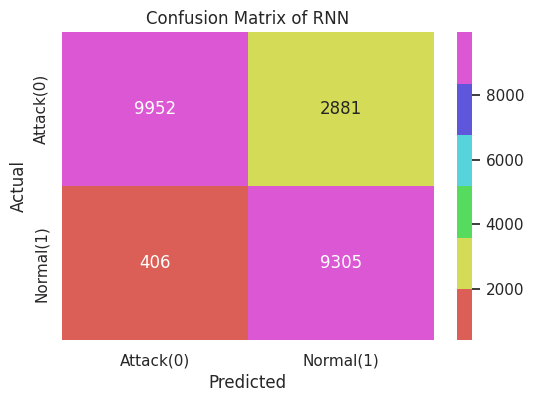


Confusion Matrix Parameters for Recurrent Neural Network (RNN):
True Negatives (TN): 9952
False Positives (FP): 2881
False Negatives (FN): 406
True Positives (TP): 9305


In [ ]:
print('\n============================== Recurrent Neural Network (RNN) ==============================')

# Reshape test data
X_test_rnn = X_test_transformed.reshape(X_test_transformed.shape[0], 1, X_test_transformed.shape[1])

# Predictions
rnn_test_pred = (rnn_model.predict(X_test_rnn) > 0.5).astype(int)

# Classification report & confusion matrix
rnn_report = classification_report(y_test, rnn_test_pred, target_names=target_names)
rnn_cm = confusion_matrix(y_test, rnn_test_pred)

# Evaluation Metrics
print("Accuracy: ", accuracy_score(y_test,rnn_test_pred))
print("Precision: ", precision_score(y_test,rnn_test_pred))
print("Recall: ", recall_score(y_test, rnn_test_pred))
print("F1-score: ", f1_score(y_test, rnn_test_pred))
print("CNN Classification Report of NAD:\n", rnn_report)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cmap_husl = sns.hls_palette()
sns.heatmap(rnn_cm, annot=True, fmt="d", cmap= cmap_husl,
            xticklabels=["Attack(0)","Normal(1)"],
            yticklabels=["Attack(0)","Normal(1)"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix of RNN")
plt.show()

# Print Confusion Matrix Components
tn, fp, fn, tp = confusion_matrix(y_test, rnn_test_pred).ravel()
print('\nConfusion Matrix Parameters for Recurrent Neural Network (RNN):')
print("True Negatives (TN):",tn)
print("False Positives (FP):",fp)
print("False Negatives (FN):",fn)
print("True Positives (TP):",tp)

Artificial Neural Network (ANN)


============================== Artificial Neural Network (ANN) ==============================
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 756us/step
Accuracy:  0.8592530163236338
Precision:  0.7655996100097497
Recall:  0.9703429101019463
F1-score:  0.8558971797084336
CNN Classification Report of NAD:
               precision    recall  f1-score   support

      attack       0.97      0.78      0.86     12833
      normal       0.77      0.97      0.86      9711

    accuracy                           0.86     22544
   macro avg       0.87      0.87      0.86     22544
weighted avg       0.88      0.86      0.86     22544



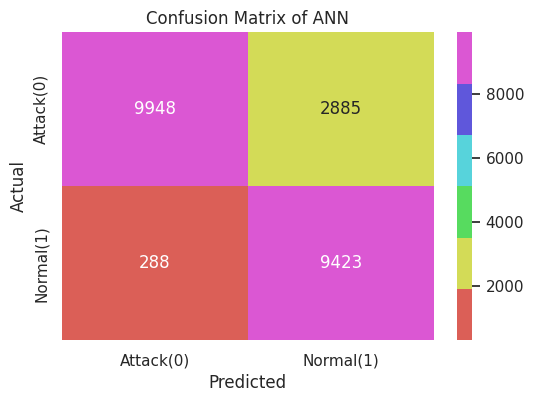


Confusion Matrix Parameters for Artificial Neural Network (ANN):
True Negatives (TN): 9948
False Positives (FP): 2885
False Negatives (FN): 288
True Positives (TP): 9423


In [ ]:
print('\n============================== Artificial Neural Network (ANN) ==============================')

# Predictions
ann_test_pred = (ann_model.predict(X_test_transformed) > 0.5).astype(int)

# Classification report & confusion matrix
ann_report = classification_report(y_test, ann_test_pred, target_names=target_names)
ann_cm = confusion_matrix(y_test, ann_test_pred)

# Evaluation Metrics
print("Accuracy: ", accuracy_score(y_test,ann_test_pred))
print("Precision: ", precision_score(y_test,ann_test_pred))
print("Recall: ", recall_score(y_test, ann_test_pred))
print("F1-score: ", f1_score(y_test, ann_test_pred))
print("CNN Classification Report of NAD:\n", ann_report)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cmap_husl = sns.hls_palette()
sns.heatmap(ann_cm, annot=True, fmt="d", cmap= cmap_husl,
            xticklabels=["Attack(0)","Normal(1)"],
            yticklabels=["Attack(0)","Normal(1)"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix of ANN")
plt.show()

# Print Confusion Matrix Components
tn, fp, fn, tp = confusion_matrix(y_test, ann_test_pred).ravel()
print('\nConfusion Matrix Parameters for Artificial Neural Network (ANN):')
print("True Negatives (TN):",tn)
print("False Positives (FP):",fp)
print("False Negatives (FN):",fn)
print("True Positives (TP):",tp)

Multilayer Perceptron (MLP)


============================== Multilayer Perceptron (MLP) ==============================
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 930us/step
Accuracy:  0.8467885024840313
Precision:  0.7517502212923473
Recall:  0.9620018535681186
F1-score:  0.8439786791941458
MPL Classification Report of NAD:
               precision    recall  f1-score   support

      attack       0.96      0.76      0.85     12833
      normal       0.75      0.96      0.84      9711

    accuracy                           0.85     22544
   macro avg       0.86      0.86      0.85     22544
weighted avg       0.87      0.85      0.85     22544



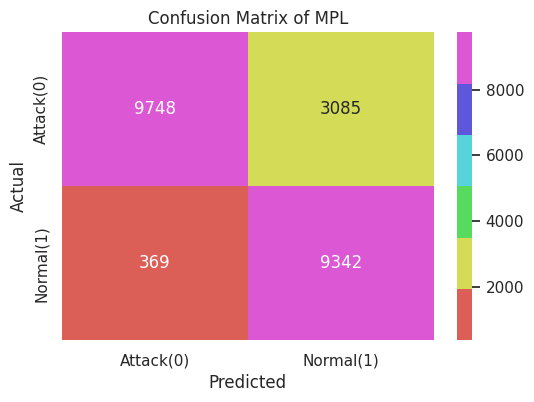


Confusion Matrix Parameters for Multilayer Perceptron (MLP):
True Negatives (TN): 9748
False Positives (FP): 3085
False Negatives (FN): 369
True Positives (TP): 9342


In [ ]:
print('\n============================== Multilayer Perceptron (MLP) ==============================')

# Predictions
mlp_test_pred = (mlp_model.predict(X_test_transformed) > 0.5).astype(int)

# Classification report & confusion matrix
mlp_report = classification_report(y_test, mlp_test_pred, target_names=target_names)
mlp_cm = confusion_matrix(y_test, mlp_test_pred)

# Evaluation Metrics
print("Accuracy: ", accuracy_score(y_test,mlp_test_pred))
print("Precision: ", precision_score(y_test,mlp_test_pred))
print("Recall: ", recall_score(y_test, mlp_test_pred))
print("F1-score: ", f1_score(y_test, mlp_test_pred))
print("MPL Classification Report of NAD:\n", mlp_report)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cmap_husl = sns.hls_palette()
sns.heatmap(mlp_cm, annot=True, fmt="d", cmap= cmap_husl,
            xticklabels=["Attack(0)","Normal(1)"],
            yticklabels=["Attack(0)","Normal(1)"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix of MPL")
plt.show()

# Print Confusion Matrix Components
tn, fp, fn, tp = confusion_matrix(y_test, mlp_test_pred).ravel()
print('\nConfusion Matrix Parameters for Multilayer Perceptron (MLP):')
print("True Negatives (TN):",tn)
print("False Positives (FP):",fp)
print("False Negatives (FN):",fn)
print("True Positives (TP):",tp)

##Receiver Operating Characteristic (ROC) Curve for Anomaly Detection

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 726us/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 921us/step


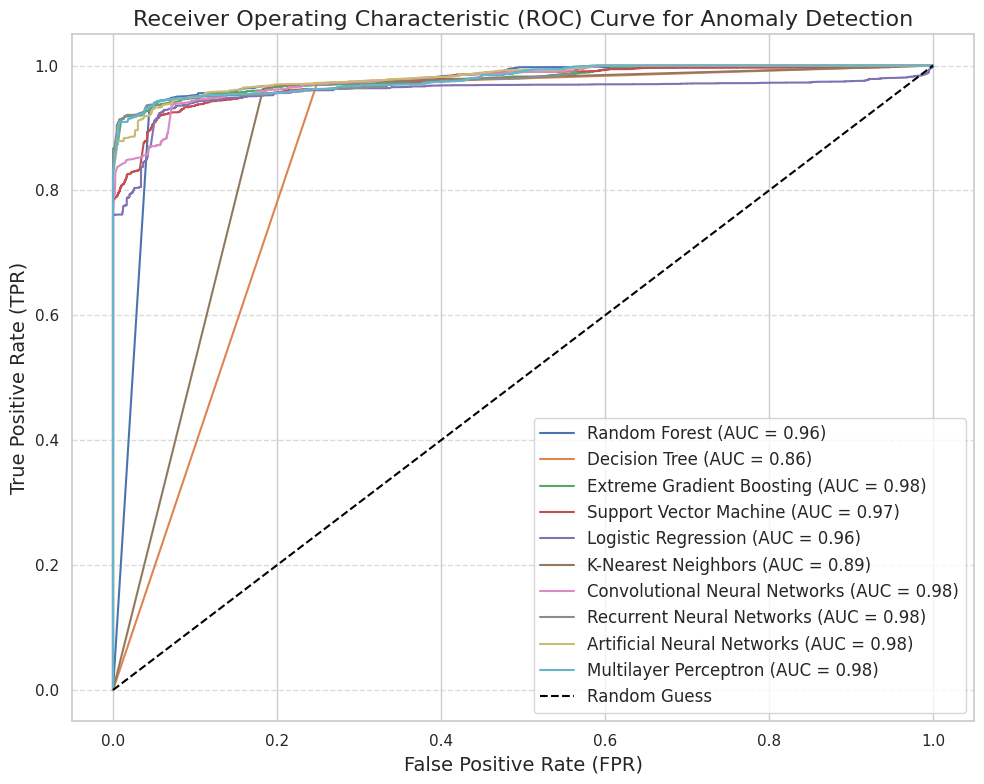

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Function to plot ROC curves for both ML and DL models
def plot_roc_curve(y_true, model_scores_dict):
    plt.figure(figsize=(10, 8))

    for model_name, scores in model_scores_dict.items():
        fpr, tpr, _ = roc_curve(y_true, scores)
        auc = roc_auc_score(y_true, scores)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.2f})')

    plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random Guess')
    plt.title('Receiver Operating Characteristic (ROC) Curve for Anomaly Detection', fontsize=16)
    plt.xlabel('False Positive Rate (FPR)', fontsize=14)
    plt.ylabel('True Positive Rate (TPR)', fontsize=14)
    plt.legend(loc='lower right', fontsize=12)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

# Example usage
model_scores_dict = {
    'Random Forest': rf.predict_proba(X_test_transformed)[:, 1],
    'Decision Tree': dt.predict_proba(X_test_transformed)[:, 1],
    'Extreme Gradient Boosting': xgb.predict_proba(X_test_transformed)[:, 1],
    'Support Vector Machine': svm.decision_function(X_test_transformed),
    'Logistic Regression': lr.predict_proba(X_test_transformed)[:, 1],
    'K-Nearest Neighbors': knn.predict_proba(X_test_transformed)[:, 1],
    'Convolutional Neural Networks': cnn_model.predict(X_test_cnn).ravel(),
    'Recurrent Neural Networks': rnn_model.predict(X_test_rnn).ravel(),
    'Artificial Neural Networks': ann_model.predict(X_test_transformed).ravel(),
    'Multilayer Perceptron': mlp_model.predict(X_test_transformed).ravel()
}

# Plot ROC curve
plot_roc_curve(y_test, model_scores_dict)

# Training and Validation Accuracy

In [ ]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_transformed.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(X_transformed, y, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9636 - loss: 0.1027 - val_accuracy: 0.9853 - val_loss: 0.0387
Epoch 2/20
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9832 - loss: 0.0445 - val_accuracy: 0.9868 - val_loss: 0.0332
Epoch 3/20
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9853 - loss: 0.0390 - val_accuracy: 0.9885 - val_loss: 0.0297
Epoch 4/20
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9872 - loss: 0.0360 - val_accuracy: 0.9896 - val_loss: 0.0287
Epoch 5/20
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9877 - loss: 0.0337 - val_accuracy: 0.9906 - val_loss: 0.0269
Epoch 6/20
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9889 - loss: 0.0312 - val_accuracy: 0.9905 - val_loss: 0.0246
Epoch 7/20
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9886 - loss: 0.0319 - val_accuracy: 0.9909 - val_loss: 0.0244
Epoch 8/20
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9892 - loss: 0.0299 - 

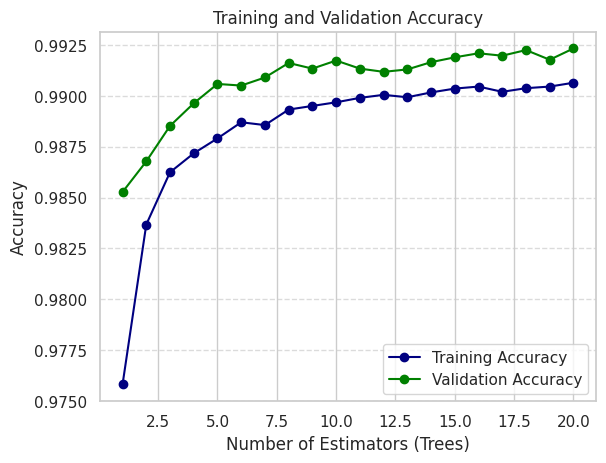

In [ ]:
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
epochs = range(1, len(training_accuracy) + 1)

# Plot Training and Validation Accuracy
#plt.figure(figsize=(10, 6))
plt.plot(epochs, training_accuracy, 'navy', label='Training Accuracy', marker='o')
plt.plot(epochs, validation_accuracy, 'green',label='Validation Accuracy', marker='o')
plt.xlabel('Number of Estimators (Trees)')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test_transformed, y_test)
print(f'Test accuracy: {test_acc}')

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8669 - loss: 0.6784
Test accuracy: 0.863200843334198


In [ ]:
predictions = model.predict(X_test_transformed)
predictions = (predictions > 0.5)

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 712us/step


In [ ]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,069 (31.52 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,380 (21.02 KB)

In [ ]:
y_pred = (predictions > 0.5).astype(int)

In [ ]:
report = classification_report(y_test, y_pred)

In [ ]:
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.79      0.87     12833
           1       0.77      0.97      0.86      9711

    accuracy                           0.86     22544
   macro avg       0.87      0.88      0.86     22544
weighted avg       0.88      0.86      0.86     22544



# Visualization of Anomaly Score Distributions

Use a histogram or Kernel Density Estimate (KDE) plot to visualize the distribution of anomaly scores for Normal and Attack classes.

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 785us/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 952us/step


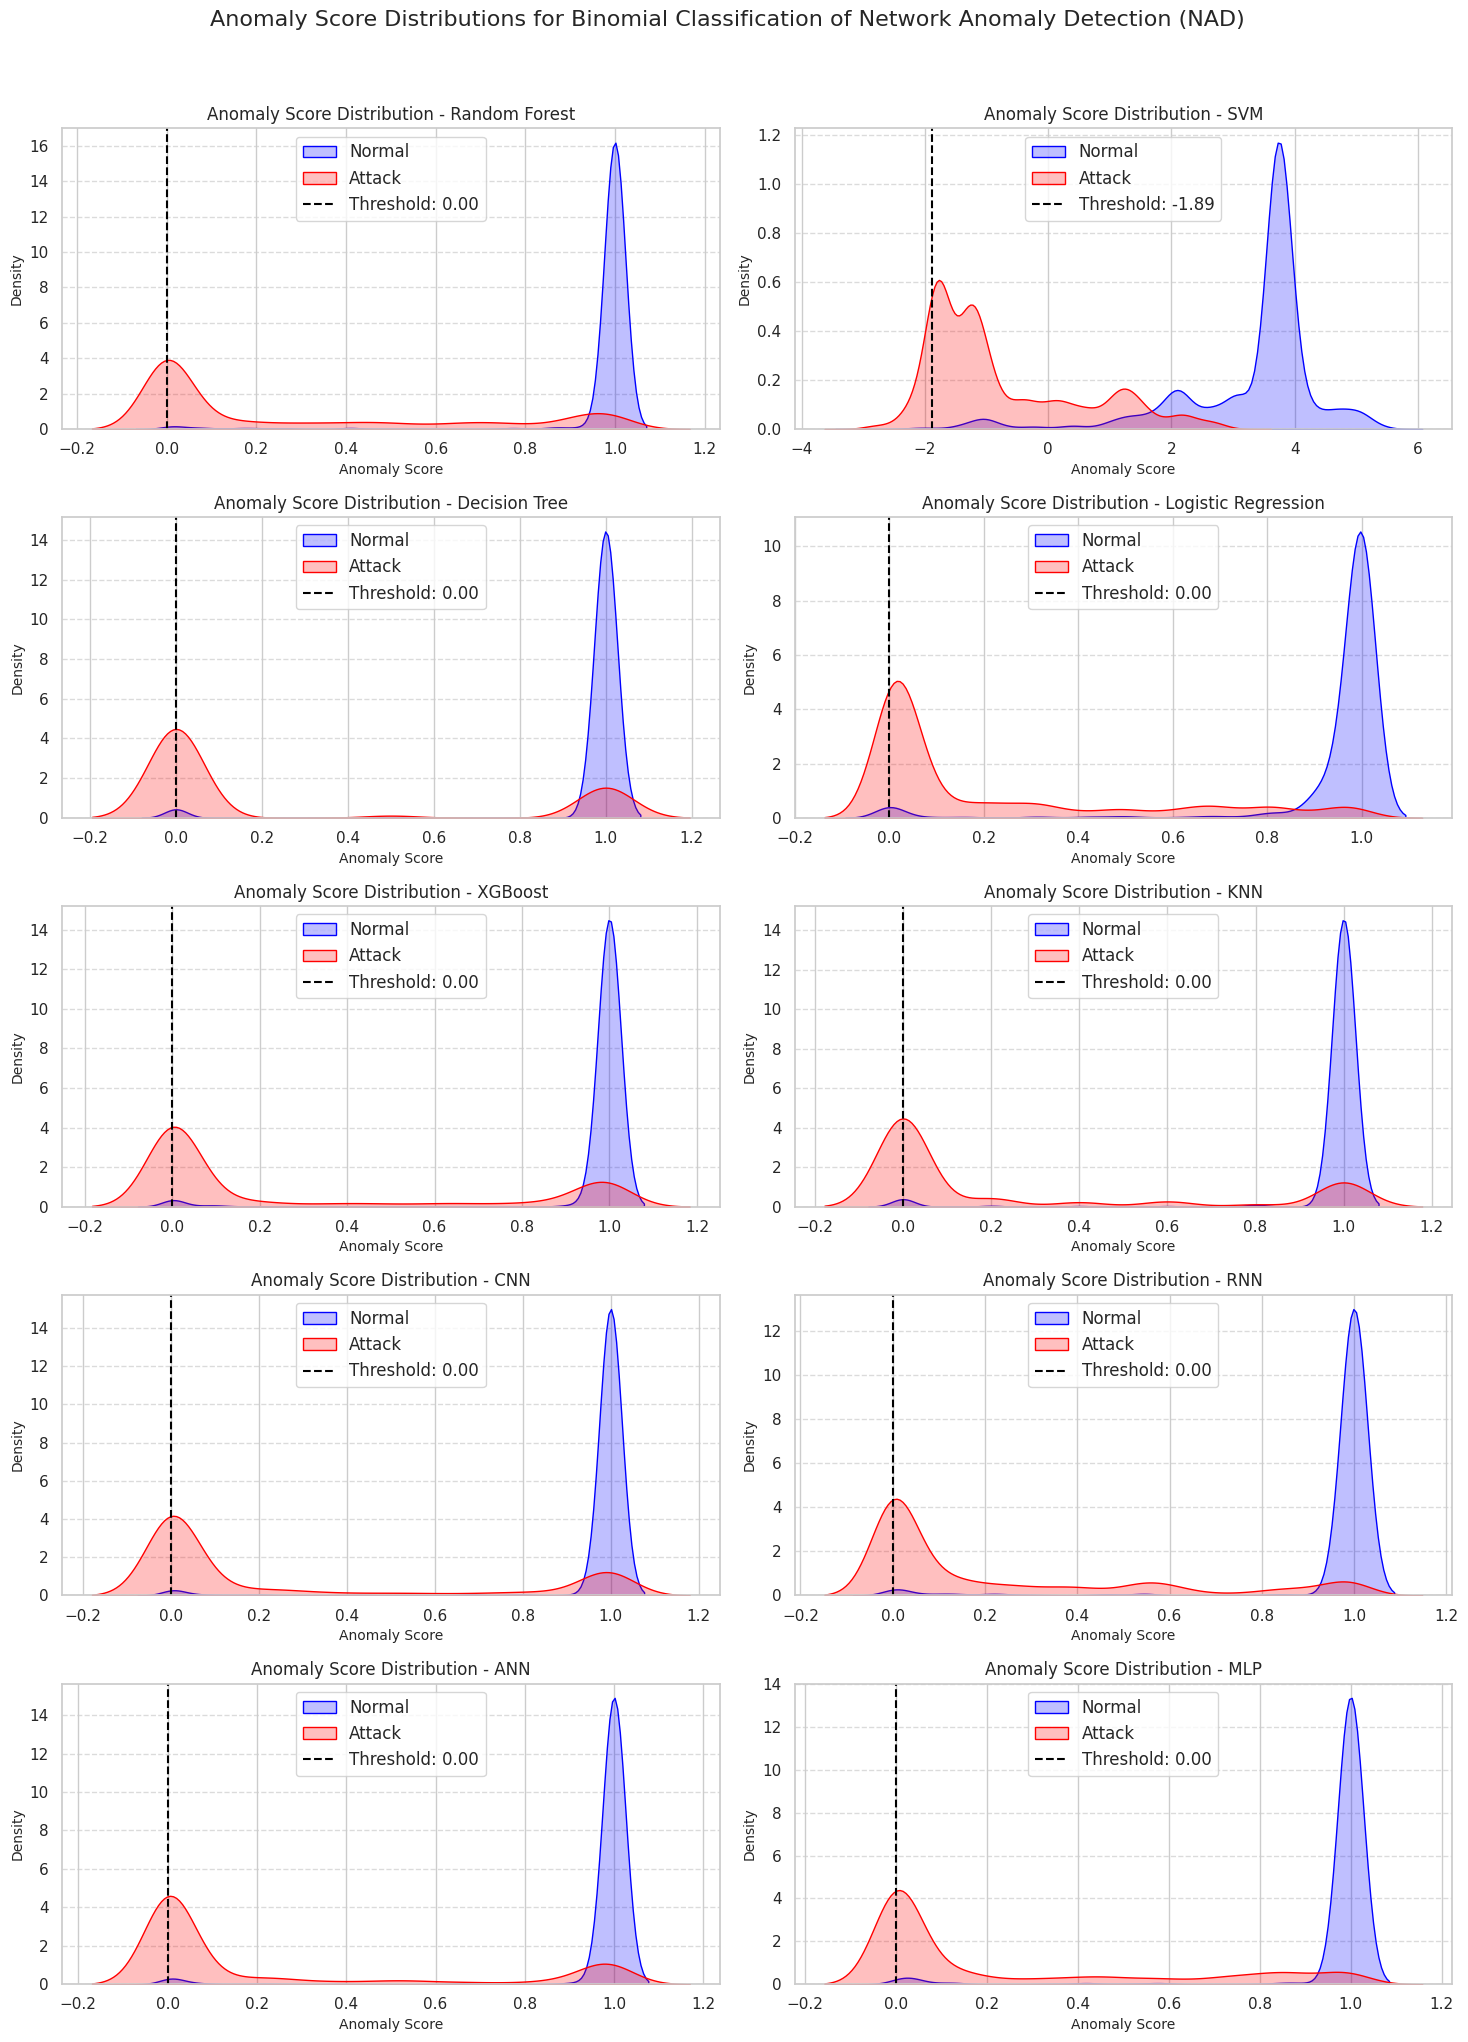

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Function to plot anomaly score distribution
def plot_anomaly_score_distribution(ax, y_true, scores, model_name):
    sns.kdeplot(scores[y_true == 1], label='Normal', color='blue', fill=True, ax=ax)
    sns.kdeplot(scores[y_true == 0], label='Attack', color='red', fill=True, ax=ax)

    threshold = np.percentile(scores, 5)
    ax.axvline(threshold, color='black', linestyle='--', label=f'Threshold: {threshold:.2f}')

    ax.set_title(f'Anomaly Score Distribution - {model_name}', fontsize=12)
    ax.set_xlabel('Anomaly Score', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(loc="upper center", fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Example usage
model_scores_dict = {
    'Random Forest': rf.predict_proba(X_test_transformed)[:, 1],
    'SVM': svm.decision_function(X_test_transformed),
    'Decision Tree': dt.predict_proba(X_test_transformed)[:, 1],
    'Logistic Regression': lr.predict_proba(X_test_transformed)[:, 1],
    'XGBoost': xgb.predict_proba(X_test_transformed)[:, 1],
    'KNN': knn.predict_proba(X_test_transformed)[:, 1],
    'CNN': cnn_model.predict(X_test_cnn).ravel(),
    'RNN': rnn_model.predict(X_test_rnn).ravel(),
    'ANN': ann_model.predict(X_test_transformed).ravel(),
    'MLP': mlp_model.predict(X_test_transformed).ravel()
}

# Create subplot grid based on number of models
n_models = len(model_scores_dict)
n_rows = (n_models + 1) // 2  # Adjust for 5x2 layout

fig, axes = plt.subplots(n_rows, 2, figsize=(15, n_rows*4))
axes = axes.flatten()

plt.suptitle('Anomaly Score Distributions for Binomial Classification of Network Anomaly Detection (NAD)'
             , fontsize=16, y=1.02)

# Plot each model's anomaly score distribution
for i, (model_name, scores) in enumerate(model_scores_dict.items()):
    plot_anomaly_score_distribution(axes[i], y_test, scores, model_name)

# Hide extra axes if not filled
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Check unique values in the target variable
unique_classes = np.unique(y)
print("Unique Classes in Target Variable:", unique_classes)

Unique Classes in Target Variable: [0 1]


In [ ]:
from collections import Counter

# Count the number of instances for each class
class_distribution = Counter(y)
print("Class Distribution:", class_distribution)

Class Distribution: Counter({1: 67343, 0: 58630})


# Model Summary
* Confusion Matrix Parameters
* Performance Summary of All Ten Models
* Model Performance Comparison for Anomaly Detection
* Accuracy of Different ML Models

Confusion Matrix Parameters for All Models:
                                  Model  True Negatives (TN)  \
0                         Random Forest                 9374   
1                         Decision Tree                 9632   
2   Extreme Gradient Boosting (XGBoost)                 9268   
3          Support Vector Machine (SVM)                 9547   
4                   Logistic Regression                10331   
5             K-Nearest Neighbors (KNN)                 9762   
6  Convolutional Neural Networks (CNNs)                 9583   
7      Recurrent Neural Networks (RNNs)                 9952   
8     Artificial Neural Networks (ANNs)                 9948   
9           Multilayer Perceptron (MLP)                 9748   

   False Positives (FP)  False Negatives (FN)  True Positives (TP)  
0                  3459                   284                 9427  
1                  3201                   285                 9426  
2                  3565                   29

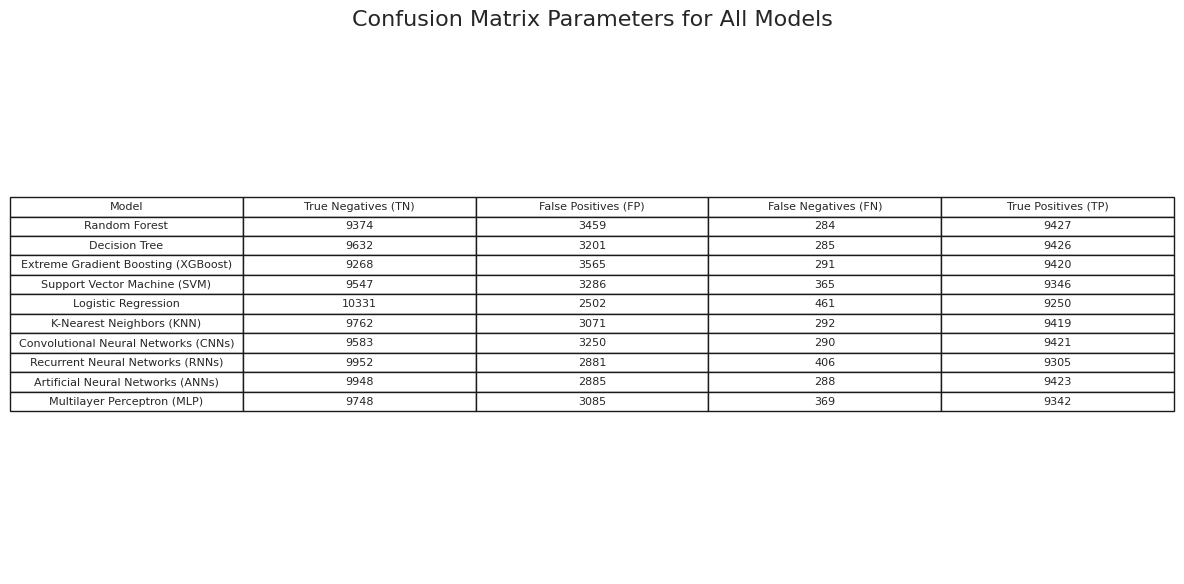

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def get_confusion_matrix_params(y_true, y_pred, model_name):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Model': model_name,
        'True Negatives (TN)': tn,
        'False Positives (FP)': fp,
        'False Negatives (FN)': fn,
        'True Positives (TP)': tp
    }

# Unified predictions dictionary for ML and DL
all_predictions = {
    'Random Forest': rf_test_pred,
    'Decision Tree': dt_test_pred,
    'Extreme Gradient Boosting (XGBoost)': xgb_test_pred,
    'Support Vector Machine (SVM)': svm_test_pred,
    'Logistic Regression': lr_test_pred,
    'K-Nearest Neighbors (KNN)':  knn_test_pred,
    'Convolutional Neural Networks (CNNs)': cnn_test_pred,
    'Recurrent Neural Networks (RNNs)': rnn_test_pred,
    'Artificial Neural Networks (ANNs)': ann_test_pred,
    'Multilayer Perceptron (MLP)': mlp_test_pred

}

# Build the table
confusion_matrix_list = [
    get_confusion_matrix_params(y_test, y_pred, model_name)
    for model_name, y_pred in all_predictions.items()
]

confusion_matrix_df = pd.DataFrame(confusion_matrix_list)
print("Confusion Matrix Parameters for All Models:")
print(confusion_matrix_df)

# Plot the table
plt.figure(figsize=(12, 6))
plt.axis('off')
table = plt.table(
    cellText=confusion_matrix_df.values,
    colLabels=confusion_matrix_df.columns,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
plt.title("Confusion Matrix Parameters for All Models", fontsize=16)
plt.tight_layout()
plt.show()


Performance Metrics for All Models (in %):
                                  Model  Accuracy (%)  Precision (%)  \
0                         Random Forest         83.40          86.76   
1                         Decision Tree         84.54          87.44   
2   Extreme Gradient Boosting (XGBoost)         82.90          86.44   
3          Support Vector Machine (SVM)         83.81          86.70   
4                   Logistic Regression         86.86          88.40   
5             K-Nearest Neighbors (KNN)         85.08          87.76   
6  Convolutional Neural Networks (CNNs)         84.30          87.28   
7      Recurrent Neural Networks (RNNs)         85.42          87.58   
8     Artificial Neural Networks (ANNs)         85.93          88.30   
9           Multilayer Perceptron (MLP)         84.68          87.23   

   Recall (%)  F1-Score (%)  
0       83.40         83.39  
1       84.54         84.56  
2       82.90         82.88  
3       83.81         83.82  
4       86.86

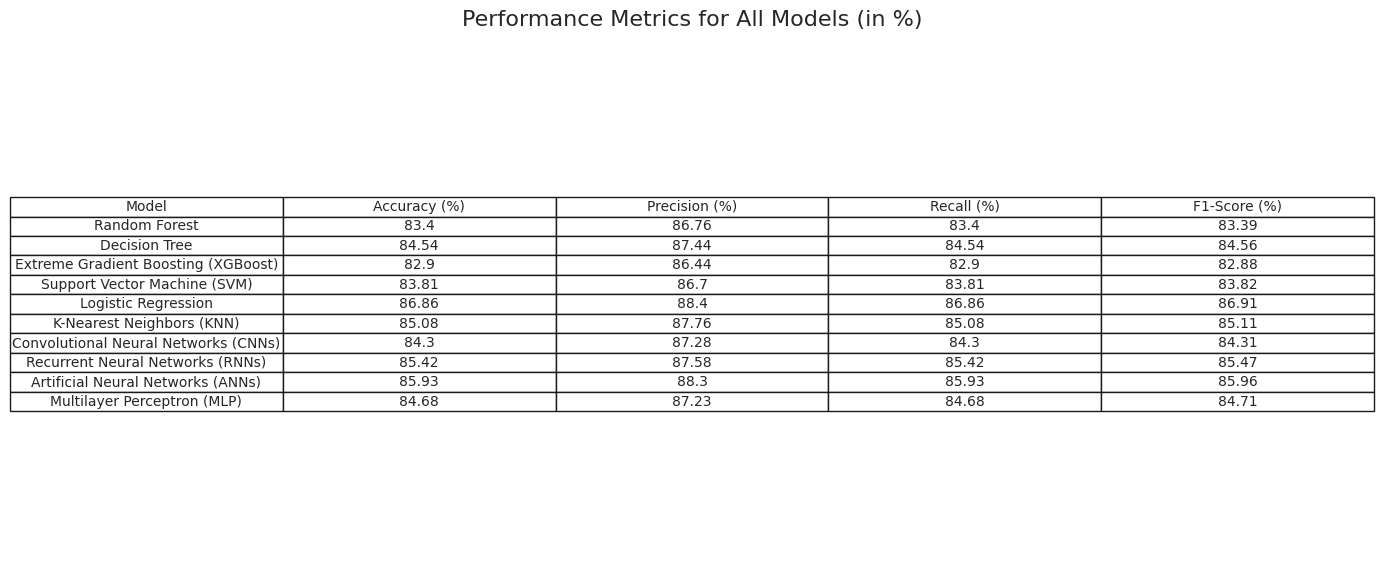

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def calculate_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy (%)': round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision (%)': round(precision_score(y_true, y_pred, average='weighted') * 100, 2),
        'Recall (%)': round(recall_score(y_true, y_pred, average='weighted') * 100, 2),
        'F1-Score (%)': round(f1_score(y_true, y_pred, average='weighted') * 100, 2)
    }

metrics_list = [
    calculate_metrics(y_test, y_pred, model_name)
    for model_name, y_pred in all_predictions.items()
]

metrics_df = pd.DataFrame(metrics_list)
print("\nPerformance Metrics for All Models (in %):")
print(metrics_df)

# Plot the table
plt.figure(figsize=(14, 6))
plt.axis('off')
table = plt.table(
    cellText=metrics_df.values,
    colLabels=metrics_df.columns,
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
plt.title("Performance Metrics for All Models (in %)", fontsize=16)
plt.tight_layout()
plt.show()


<Figure size 1400x1200 with 0 Axes>

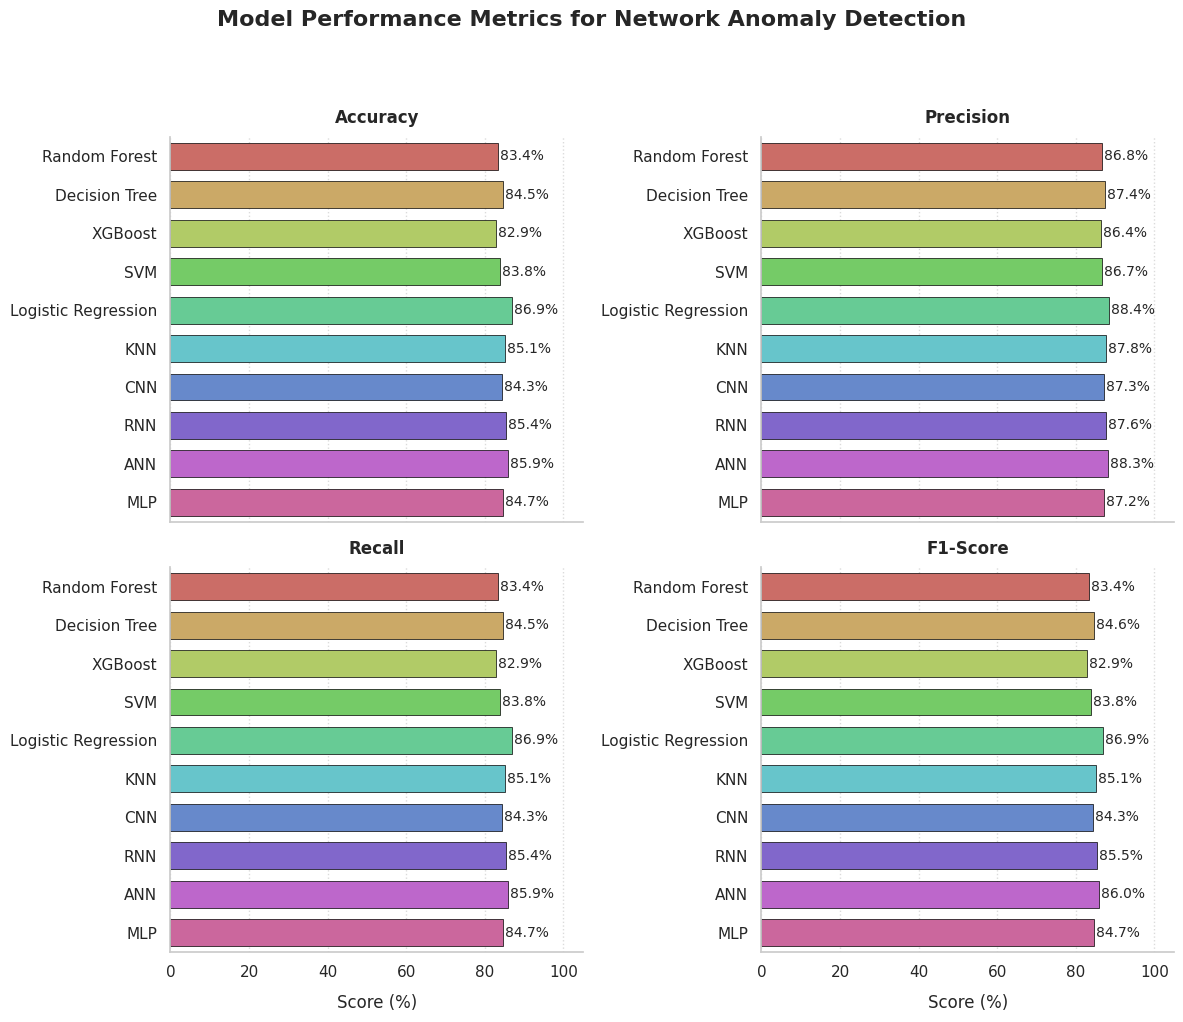

In [ ]:
import seaborn as sns

def evaluate_model(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred) * 100,
        'Precision': precision_score(y_true, y_pred, average='weighted') * 100,
        'Recall': recall_score(y_true, y_pred, average='weighted') * 100,
        'F1-Score': f1_score(y_true, y_pred, average='weighted') * 100
    }

# Unified predictions dictionary for ML and DL
all_predictions = {
    'Random Forest': rf_test_pred,
    'Decision Tree': dt_test_pred,
    'XGBoost': xgb_test_pred,
    'SVM': svm_test_pred,
    'Logistic Regression': lr_test_pred,
    'KNN': knn_test_pred,
    'CNN': cnn_test_pred,
    'RNN': rnn_test_pred,
    'ANN': ann_test_pred,
    'MLP': mlp_test_pred
}

# Create melted DataFrame for plotting
metrics_data = []
for model_name, pred in all_predictions.items():
    metrics = evaluate_model(y_test, pred)
    for metric_name, score in metrics.items():
        metrics_data.append({
            'Model': model_name,
            'Metric': metric_name,
            'Score': score
        })
metrics_plot_df = pd.DataFrame(metrics_data)

# Create the faceted bar plot
plt.figure(figsize=(14, 12))
sns.set_style("whitegrid", {'grid.linestyle': ':'})
palette = sns.color_palette("hls", len(all_predictions))

g = sns.FacetGrid(
    metrics_plot_df,
    col='Metric',
    col_wrap=2,
    height=5,
    aspect=1.2,
    sharey=False
)

g.map_dataframe(
    sns.barplot,
    x='Score',
    y='Model',
    palette=palette,
    order=list(all_predictions.keys()),
    width=0.7,
    edgecolor='black',
    linewidth=0.5
)

for ax, metric in zip(g.axes.flat, metrics_plot_df['Metric'].unique()):
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(
            f'{width:.1f}%',
            (width + 0.5, p.get_y() + p.get_height()/2),
            ha='left',
            va='center',
            fontsize=10
        )
    ax.set_xlim(0, 105)
    ax.set_title(f"{metric}", fontweight='bold', pad=10)
    ax.set_xlabel('Score (%)', labelpad=10)
    ax.set_ylabel('')
    ax.grid(True, axis='x', linestyle=':', alpha=0.7)

g.fig.suptitle('Model Performance Metrics for Network Anomaly Detection\n', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 733us/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 936us/step


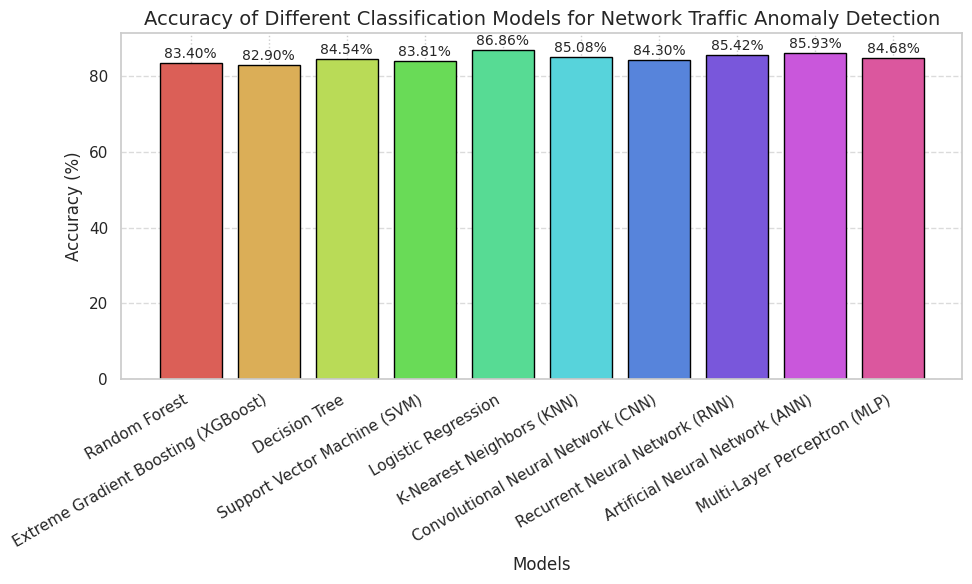

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# --- Accuracy function ---
def calculate_accuracy(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred) * 100
    return {'Model': model_name, 'Accuracy (%)': round(accuracy, 2)}

# --- Threshold function for DL binary predictions ---
def preprocess_predictions(preds):
    return (preds > 0.5).astype(int).ravel()

# --- Accuracy collection ---
results = []

# --- ML Models ---
ml_models = {
    'Random Forest': rf,
    'Extreme Gradient Boosting (XGBoost)': xgb,
    'Decision Tree': dt,
    'Support Vector Machine (SVM)': svm,
    'Logistic Regression': lr,
    'K-Nearest Neighbors (KNN)': knn
}

for name, model in ml_models.items():
    y_pred = model.predict(X_test_transformed)
    results.append(calculate_accuracy(y_test, y_pred, name))

# --- DL Models ---
cnn_preds = cnn_model.predict(X_test_cnn)
rnn_preds = rnn_model.predict(X_test_rnn)
ann_preds = ann_model.predict(X_test_transformed)
mlp_preds = mlp_model.predict(X_test_transformed)

dl_models = {
    'Convolutional Neural Network (CNN)': cnn_preds,
    'Recurrent Neural Network (RNN)': rnn_preds,
    'Artificial Neural Network (ANN)': ann_preds,
    'Multi-Layer Perceptron (MLP)': mlp_preds
}

for name, preds in dl_models.items():
    y_pred = preprocess_predictions(preds)
    results.append(calculate_accuracy(y_test, y_pred, name))

# --- Create DataFrame ---
accuracy_df = pd.DataFrame(results)

# --- Plot (Your style) ---
plt.figure(figsize=(10, 6))
cmap = sns.hls_palette(len(accuracy_df))
bars = plt.bar(accuracy_df['Model'], accuracy_df['Accuracy (%)'], color=cmap, edgecolor='black')

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{height:.2f}%',
             ha='center', va='bottom', fontsize=10)

# Plot formatting (your style)
plt.title("Accuracy of Different Classification Models for Network Traffic Anomaly Detection", fontsize=14)
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Statical Analysis on training dataset

DESCRIPTIVE STATISTICS

Dataset Shape: (125973, 45)

Data Types:
 int64      24
float64    15
object      6
Name: count, dtype: int64

Missing Values:
 0

Numerical Features Statistics:
                                 count          mean           std  min    25%  \
duration                     125973.0    287.144650  2.604515e+03  0.0   0.00   
src_bytes                    125973.0  45566.743000  5.870331e+06  0.0   0.00   
dst_bytes                    125973.0  19779.114421  4.021269e+06  0.0   0.00   
land                         125973.0      0.000198  1.408607e-02  0.0   0.00   
wrong_fragment               125973.0      0.022687  2.535300e-01  0.0   0.00   
urgent                       125973.0      0.000111  1.436603e-02  0.0   0.00   
hot                          125973.0      0.204409  2.149968e+00  0.0   0.00   
num_failed_logins            125973.0      0.001222  4.523914e-02  0.0   0.00   
logged_in                    125973.0      0.395736  4.890101e-01  0.0   0.00   
num

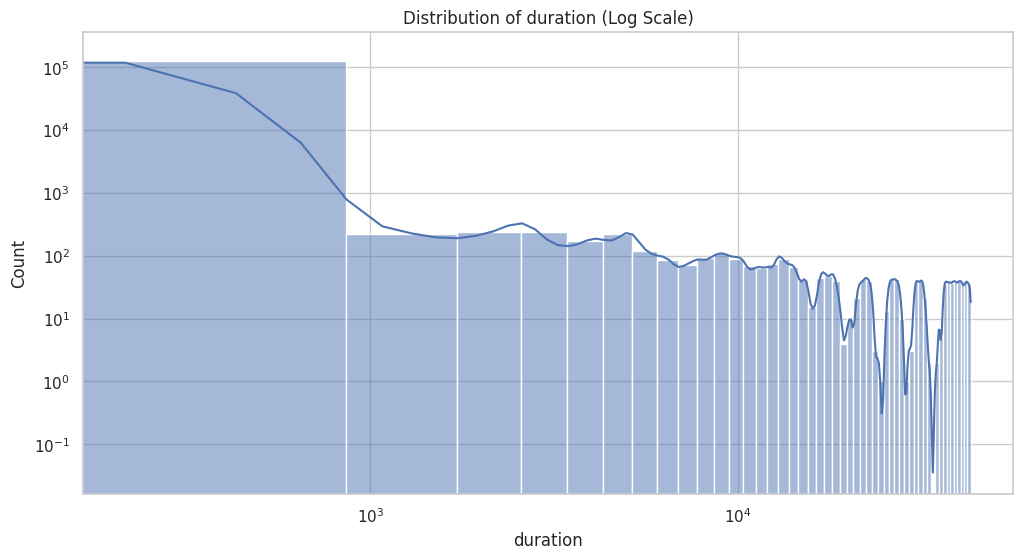

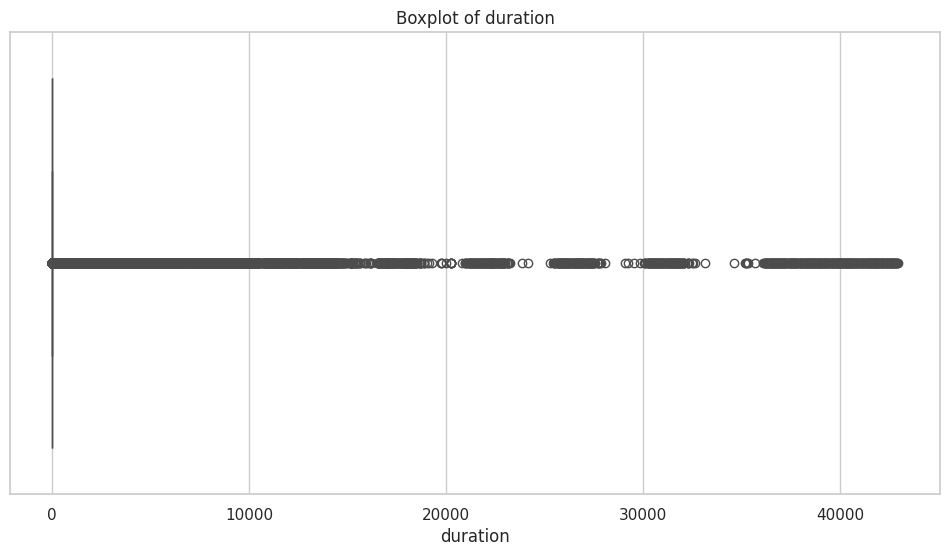

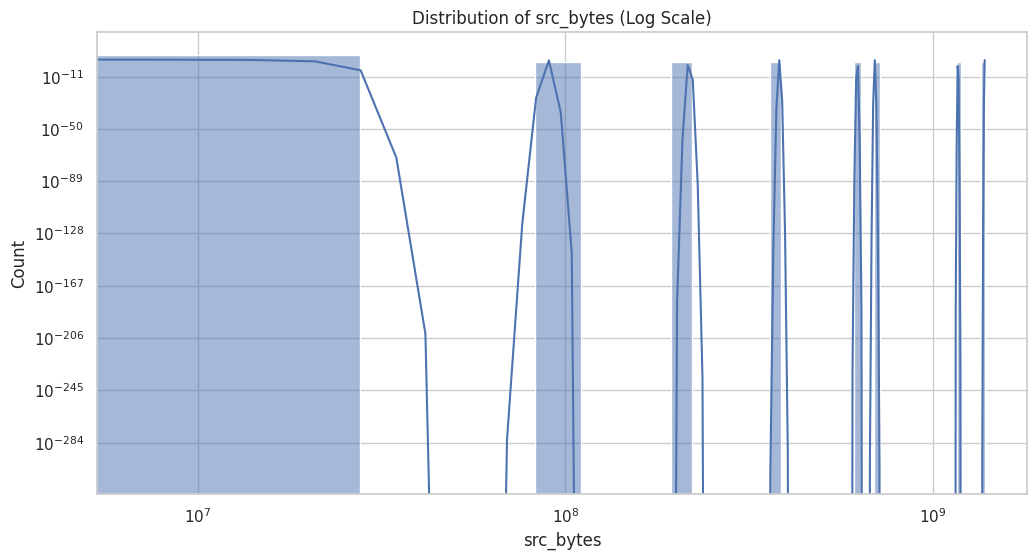

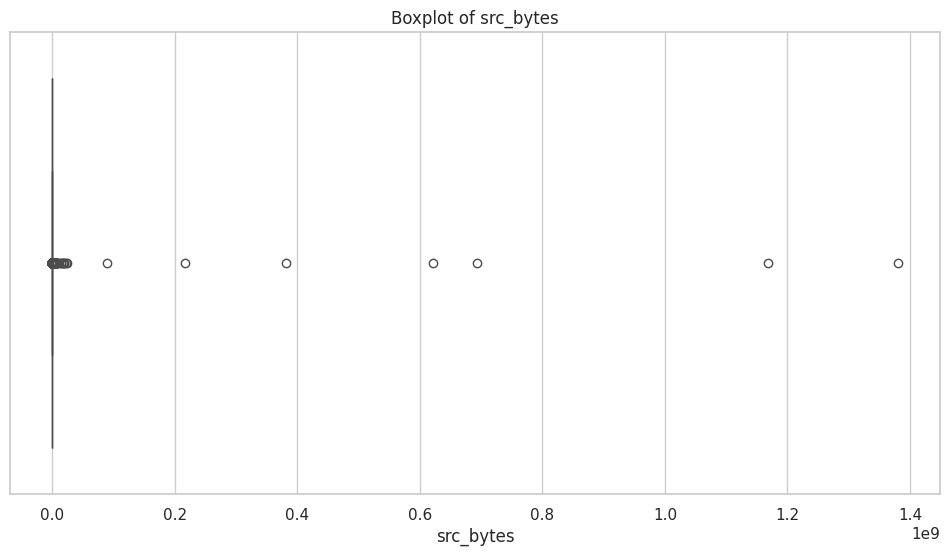

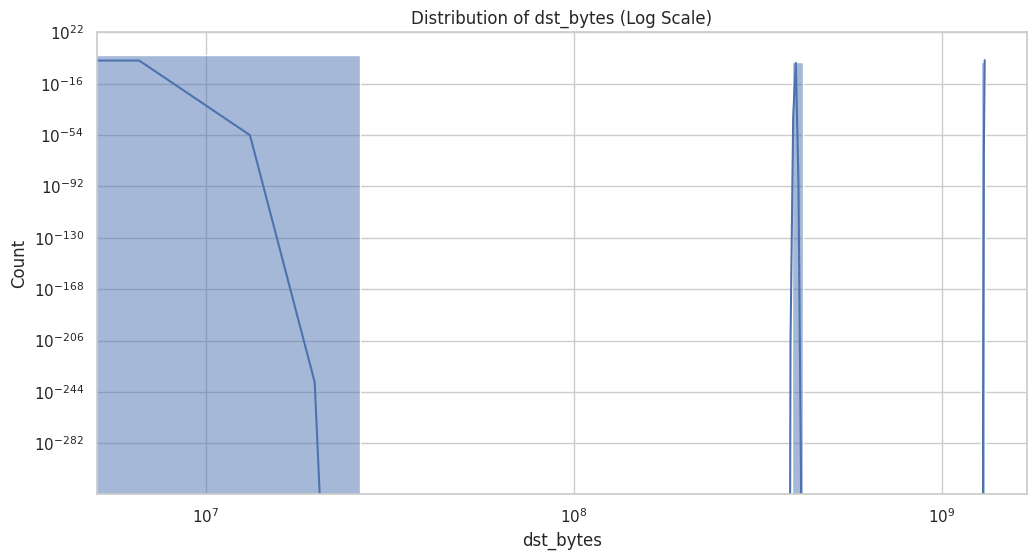

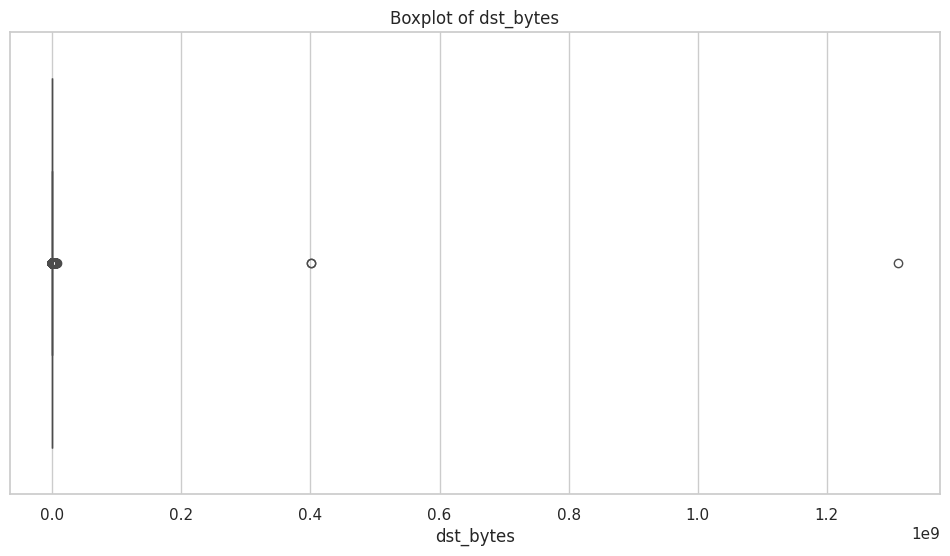

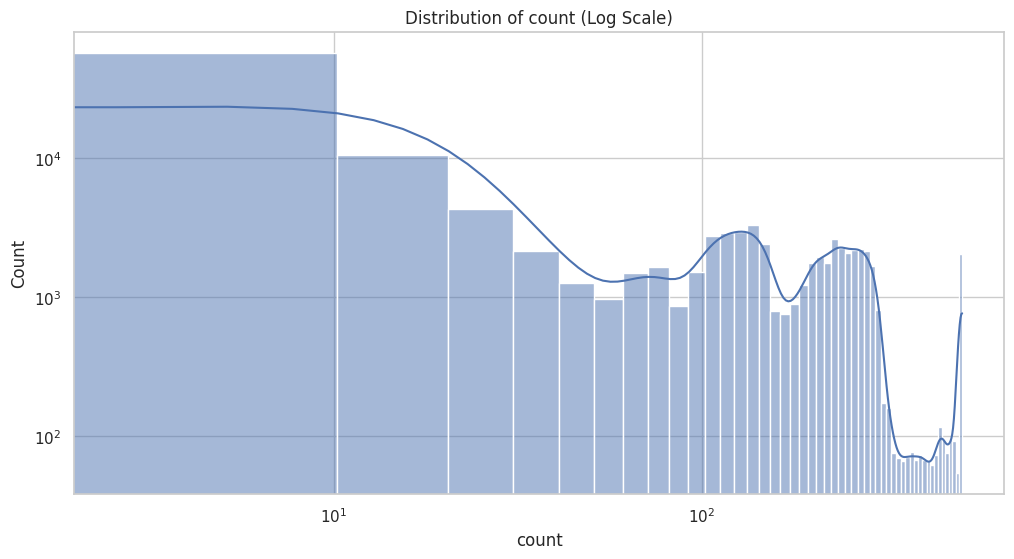

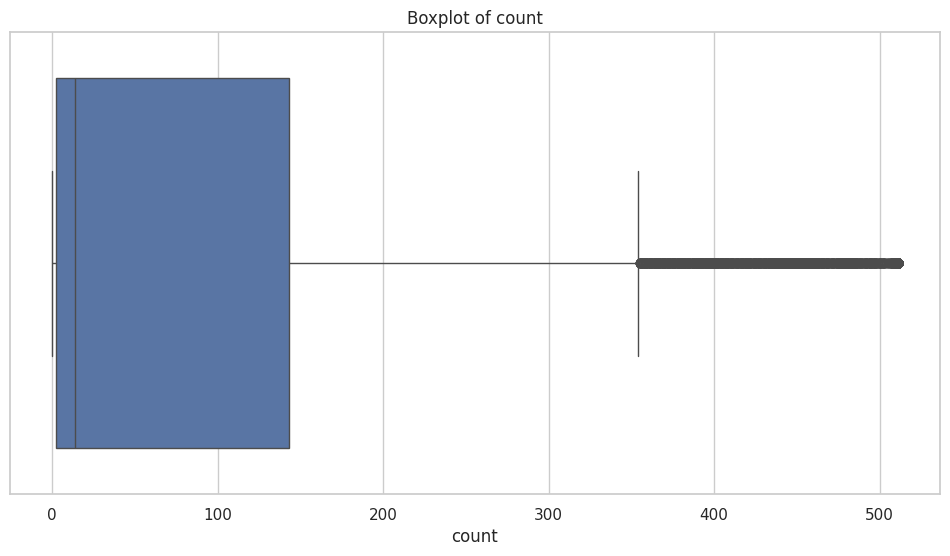

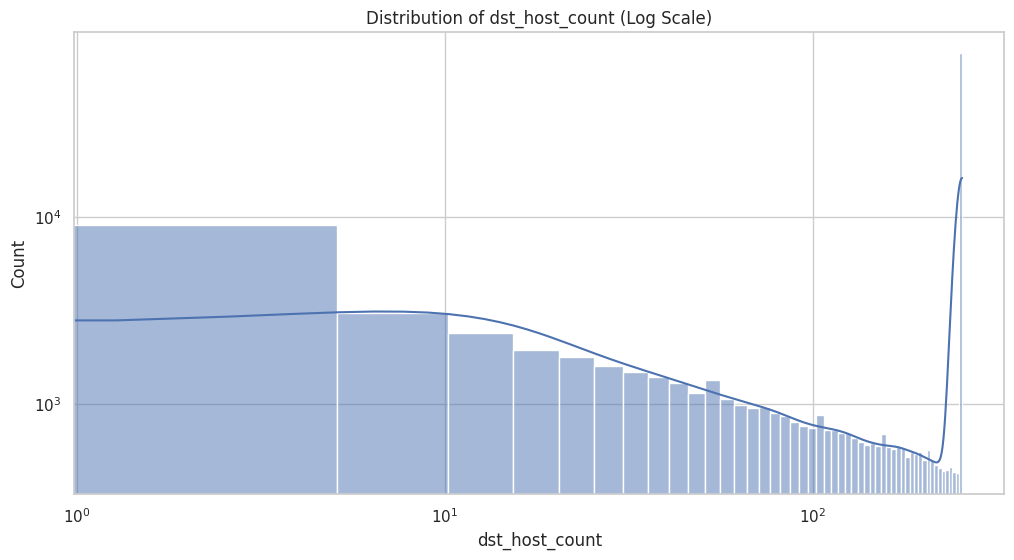

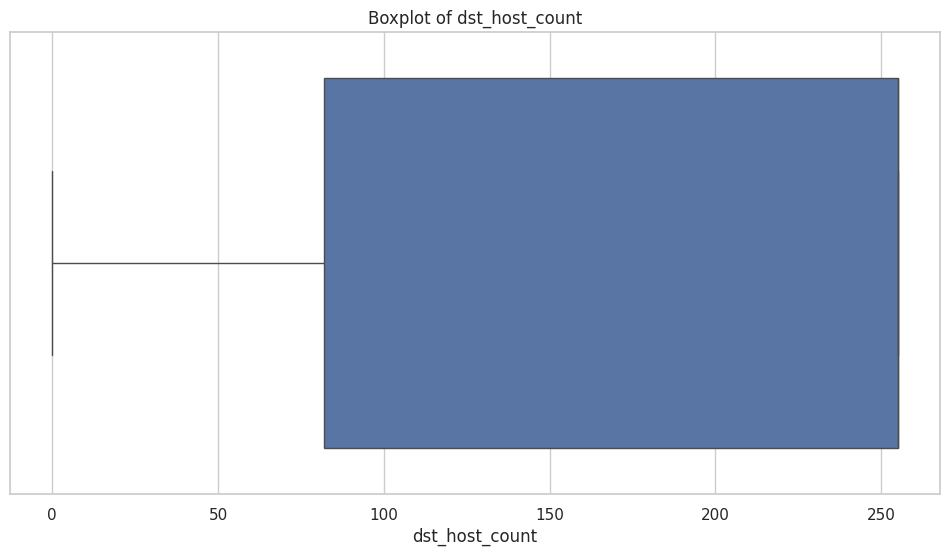

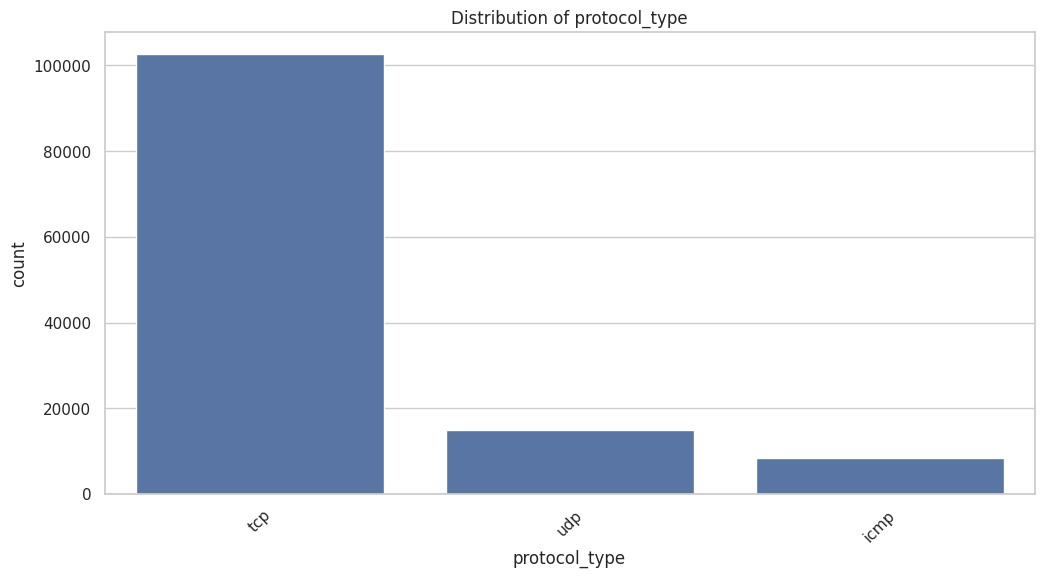

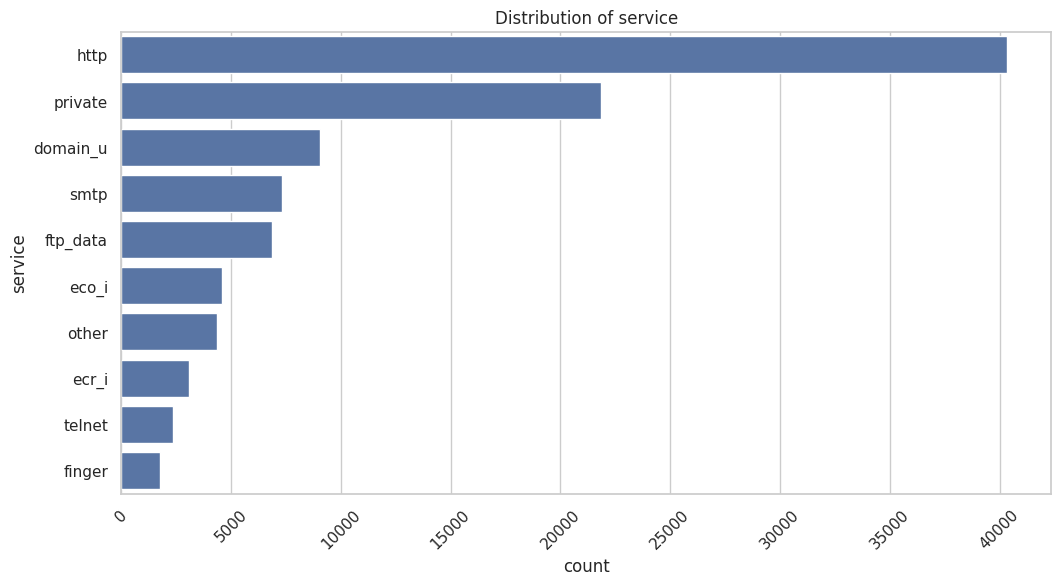

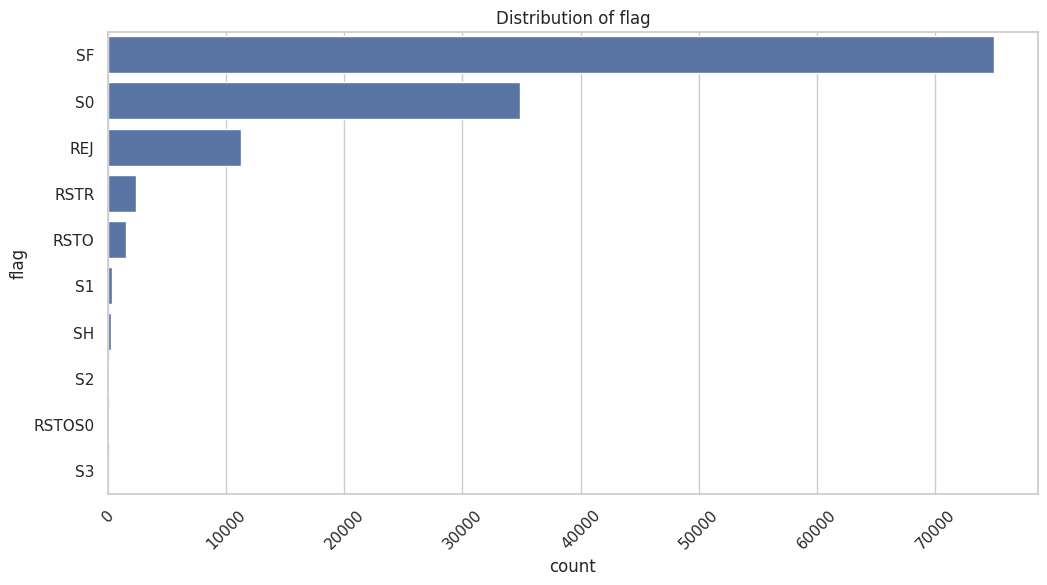

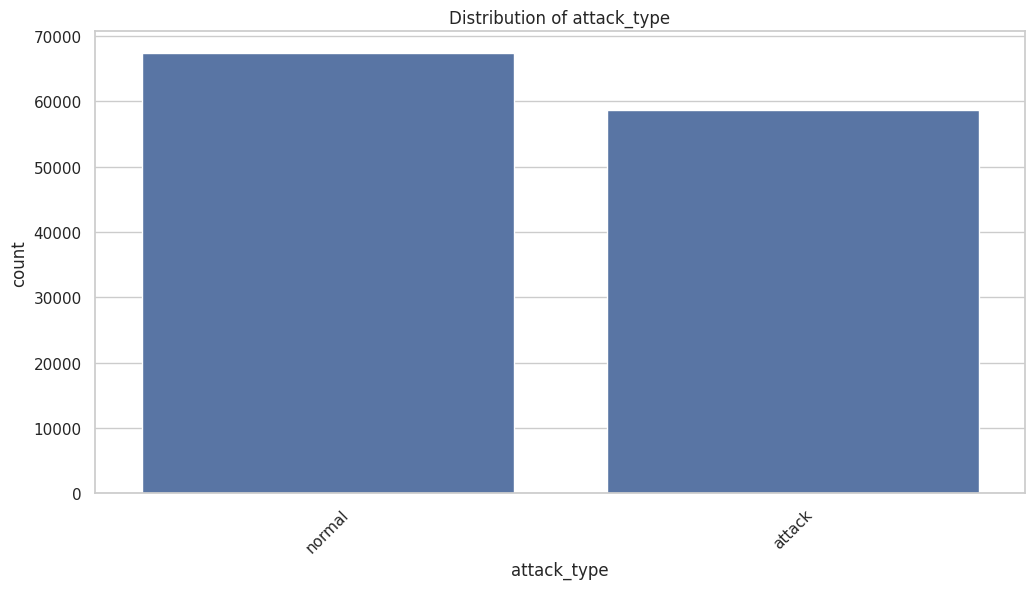

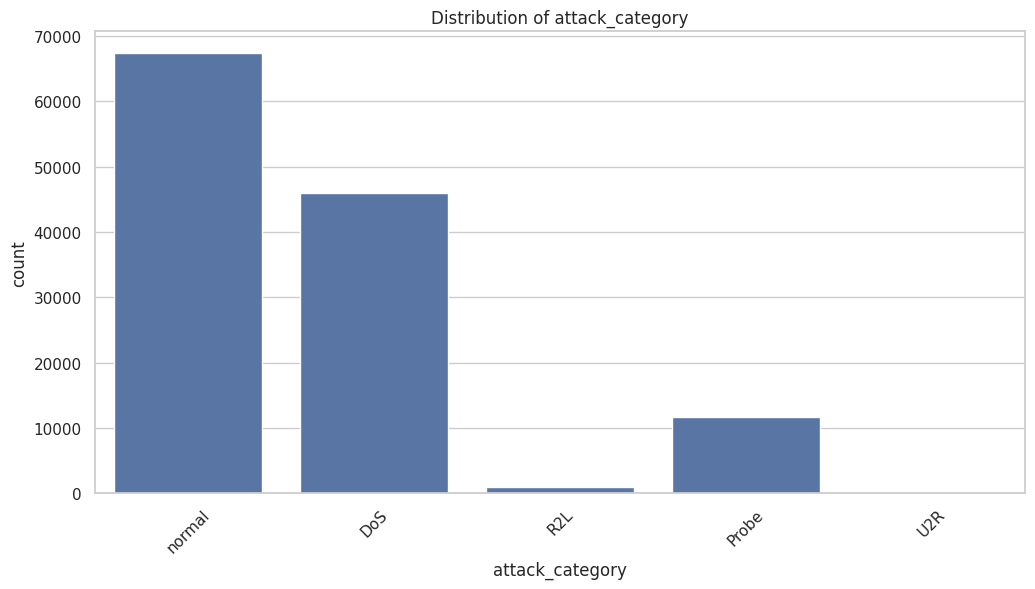

BIVARIATE ANALYSIS


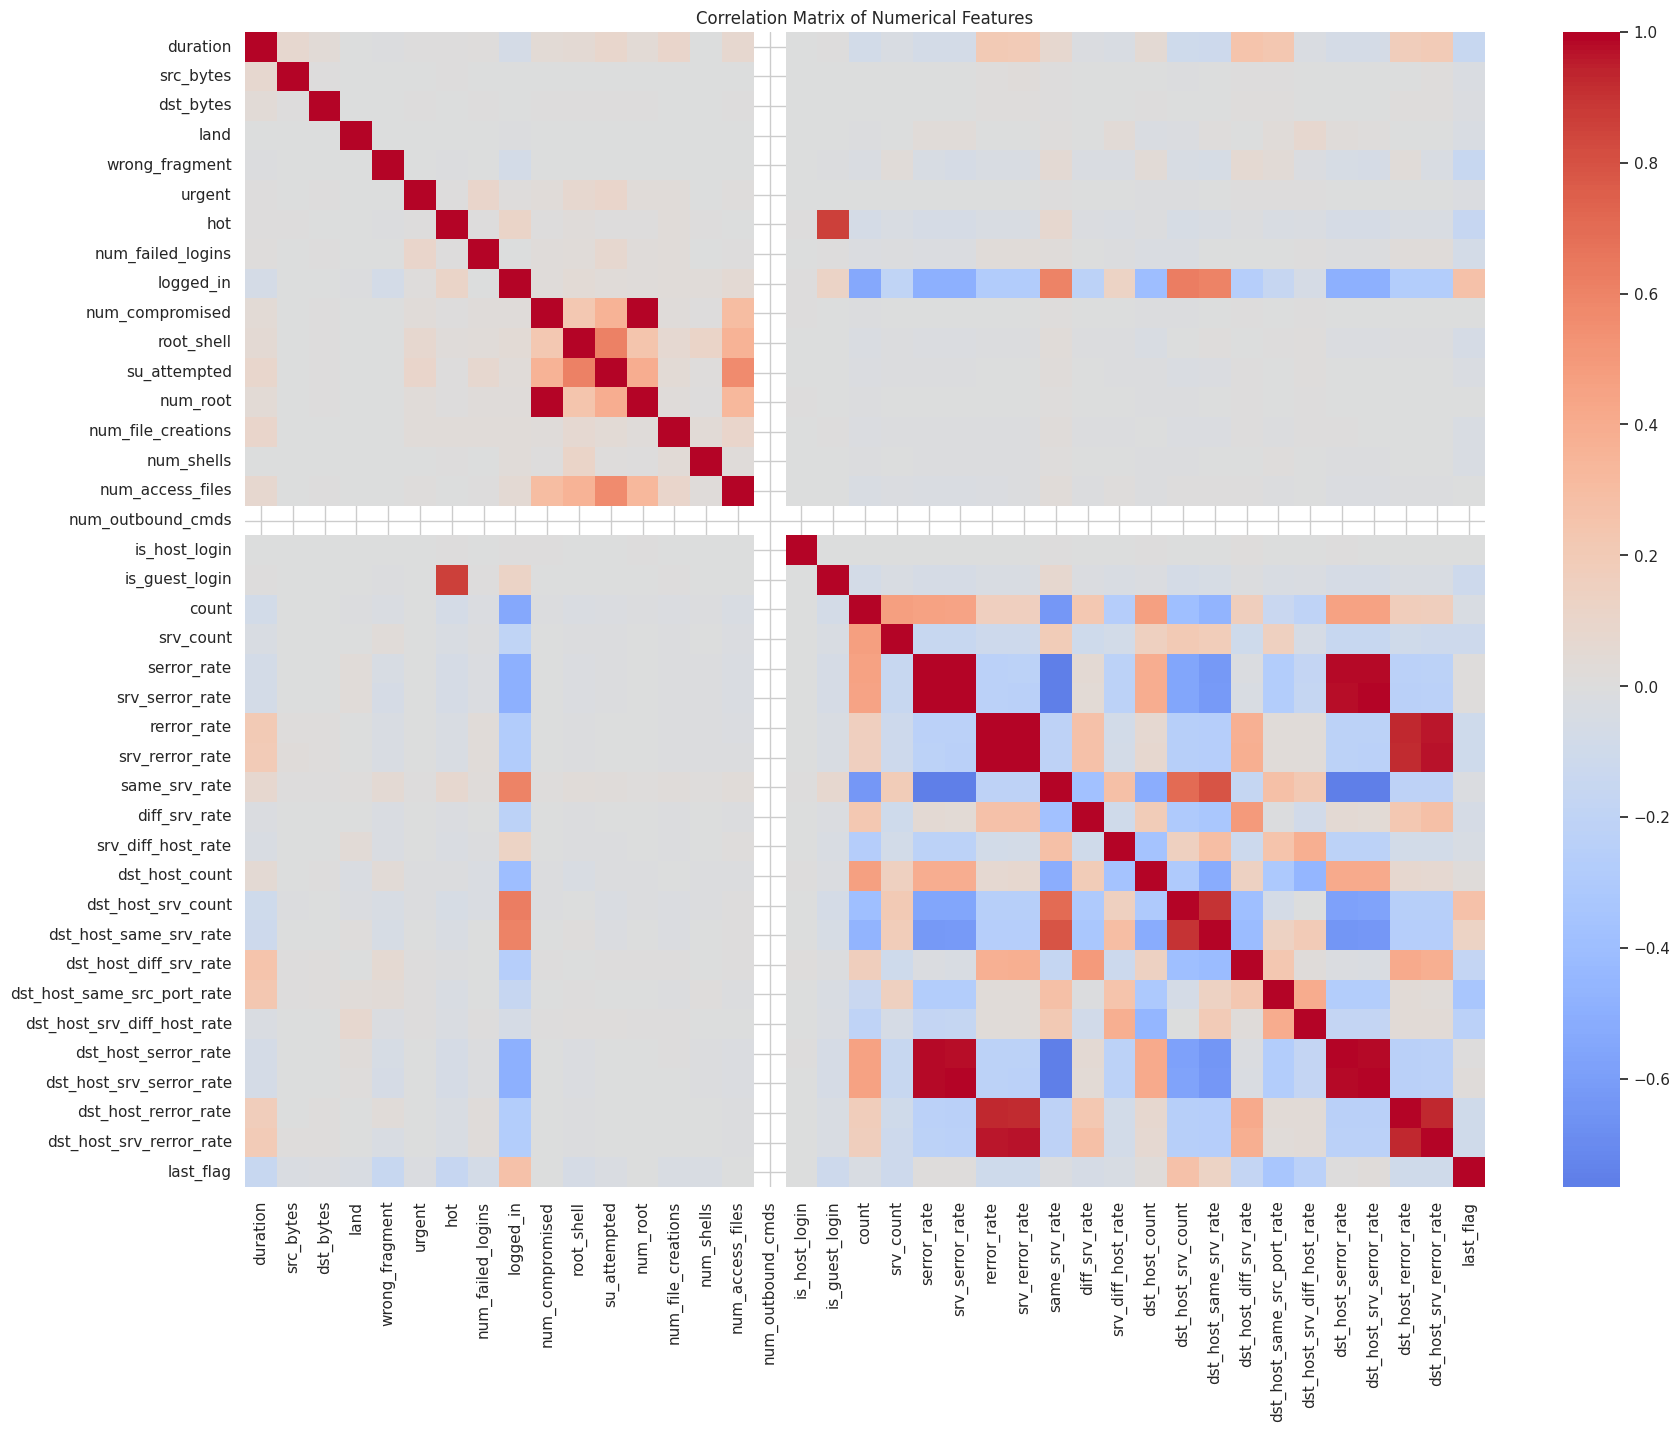


Top Correlated Features:
num_root                  num_compromised             0.998833
num_compromised           num_root                    0.998833
srv_serror_rate           serror_rate                 0.993289
serror_rate               srv_serror_rate             0.993289
srv_rerror_rate           rerror_rate                 0.989008
rerror_rate               srv_rerror_rate             0.989008
dst_host_srv_serror_rate  srv_serror_rate             0.986252
srv_serror_rate           dst_host_srv_serror_rate    0.986252
dst_host_srv_serror_rate  dst_host_serror_rate        0.985052
dst_host_serror_rate      dst_host_srv_serror_rate    0.985052
dtype: float64


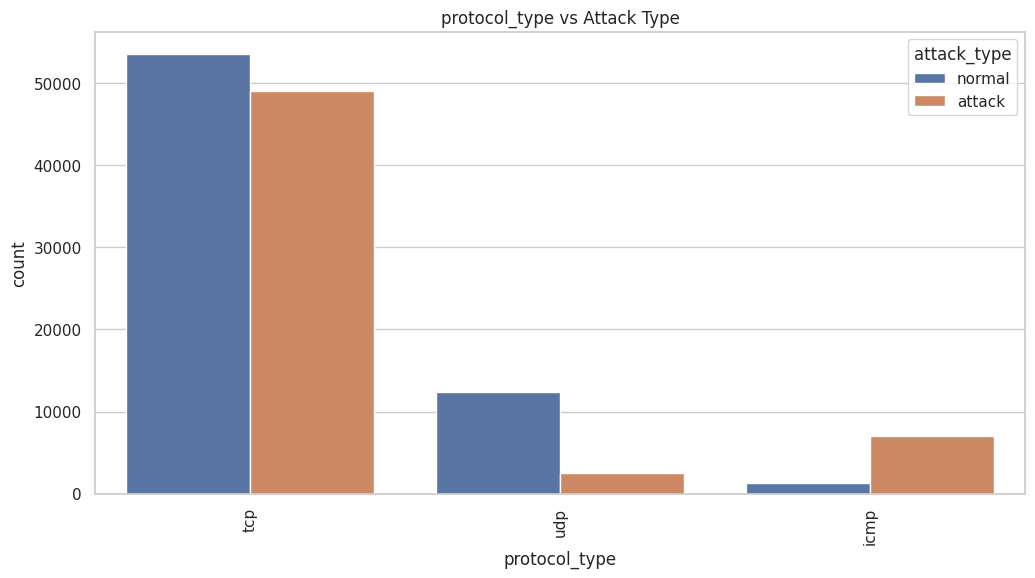

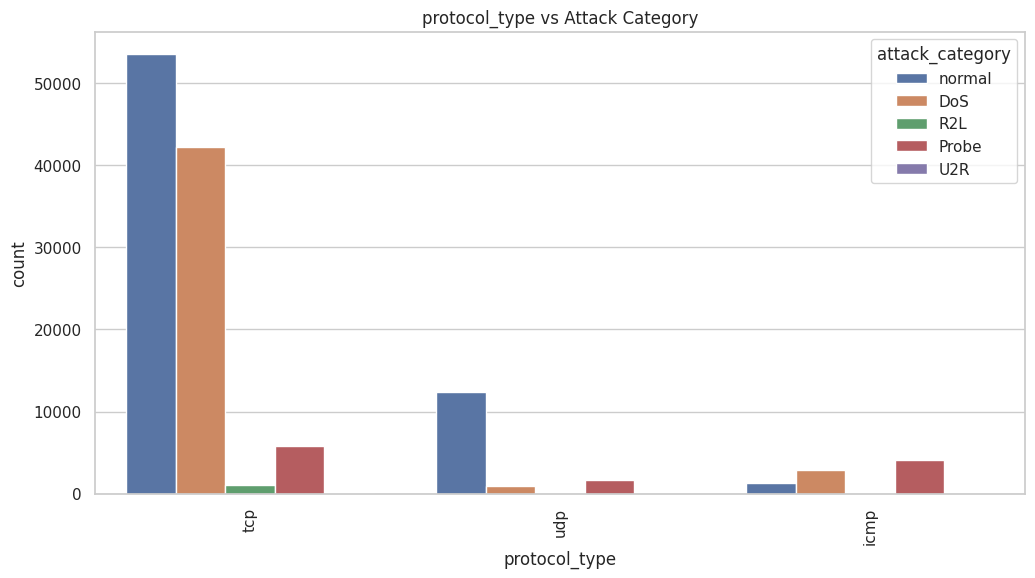

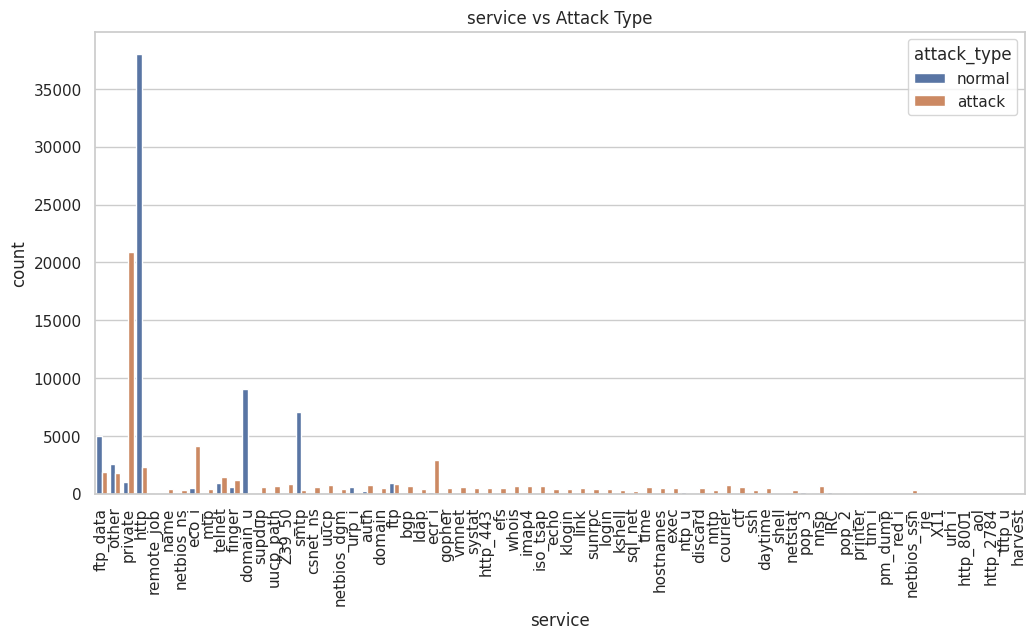

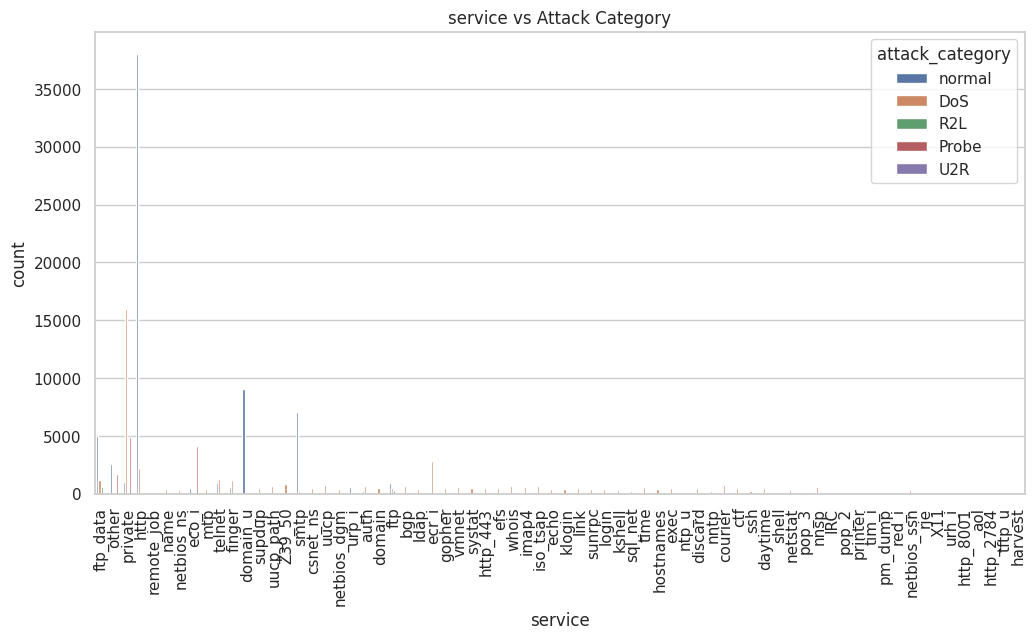

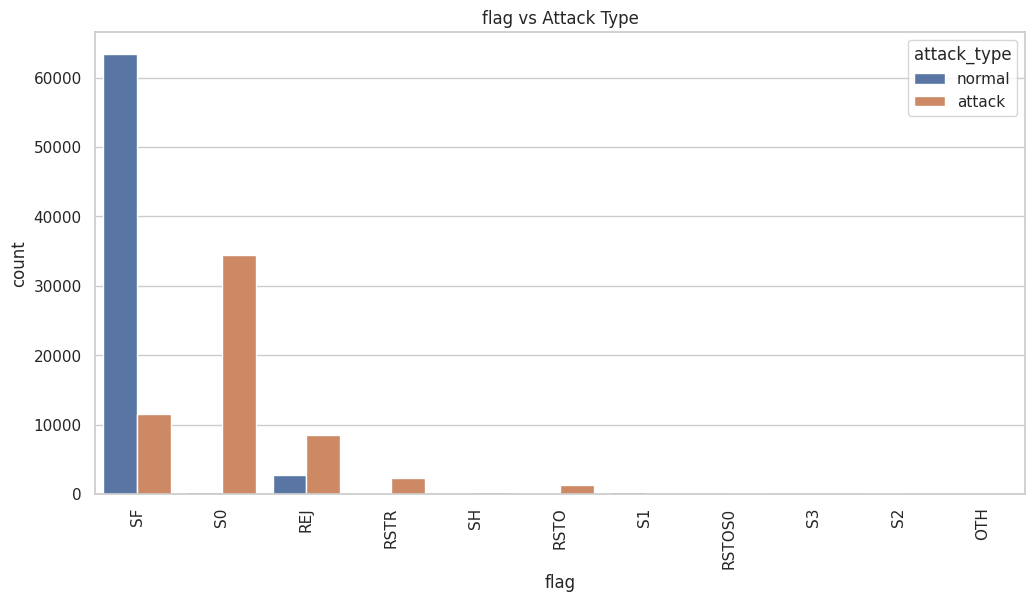

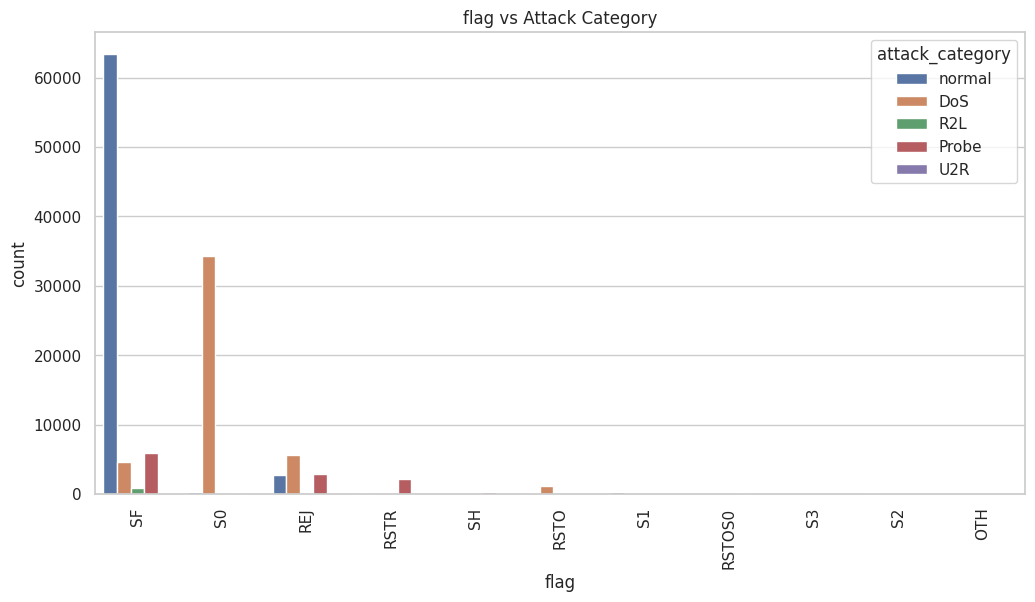


ANOVA Test Results (Numerical Features vs Attack Category):
duration: F-value = 1632.17, p-value = 0.0000
src_bytes: F-value = 11.45, p-value = 0.0000
dst_bytes: F-value = 5.27, p-value = 0.0003
count: F-value = 21428.45, p-value = 0.0000
wrong_fragment: F-value = 445.75, p-value = 0.0000
ADVANCED STATISTICAL ANALYSIS

Normality Tests (Shapiro-Wilk):
duration: Statistics=0.100, p-value=0.000
src_bytes: Statistics=0.019, p-value=0.000
dst_bytes: Statistics=0.003, p-value=0.000
count: Statistics=0.754, p-value=0.000

Chi-square Tests for Categorical Features:
protocol_type vs attack_type: Chi2=10029.25, p-value=0.0000
service vs attack_type: Chi2=93240.03, p-value=0.0000
flag vs attack_type: Chi2=75651.74, p-value=0.0000

Effect Size Analysis (Cohen's d):
duration: Cohen's d = 0.095
src_bytes: Cohen's d = 0.011
dst_bytes: Cohen's d = 0.008
count: Cohen's d = 1.380


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set style for plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

def load_and_preprocess_data(filepath):
    """Load and preprocess the KDDCUP'99 dataset"""
    # Column names as provided in the document
    columns = [
        "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land",
        "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
        "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
        "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
        "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
        "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
        "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
        "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
        "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
        "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "attack", "last_flag"
    ]

    # Load the data
    df = pd.read_csv(filepath, names=columns)

    # Create target variables for binomial and multinomial classification
    df['attack_type'] = df['attack'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

    # Map specific attack types to categories
    attack_mapping = {
        'normal': 'normal',
        'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS', 'smurf': 'DoS', 'teardrop': 'DoS',
        'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'satan': 'Probe',
        'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R',
        'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L', 'multihop': 'R2L',
        'phf': 'R2L', 'spy': 'R2L', 'warezclient': 'R2L', 'warezmaster': 'R2L'
    }

    df['attack_category'] = df['attack'].map(attack_mapping)

    return df

def descriptive_statistics(df):
    """Generate descriptive statistics for the dataset"""
    print("="*80)
    print("DESCRIPTIVE STATISTICS")
    print("="*80)

    # Basic info
    print("\nDataset Shape:", df.shape)
    print("\nData Types:\n", df.dtypes.value_counts())

    # Missing values
    print("\nMissing Values:\n", df.isnull().sum().sum())

    # Numerical features statistics
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    print("\nNumerical Features Statistics:\n", df[num_cols].describe().transpose())

    # Categorical features statistics
    cat_cols = df.select_dtypes(include=['object']).columns
    print("\nCategorical Features Value Counts:")
    for col in cat_cols:
        print(f"\n{col}:\n", df[col].value_counts(normalize=True).head())

    # Target variable distribution
    print("\nAttack Type Distribution (Binomial):\n", df['attack_type'].value_counts(normalize=True))
    print("\nAttack Category Distribution (Multinomial):\n", df['attack_category'].value_counts(normalize=True))

def univariate_analysis(df):
    """Perform univariate analysis on features"""
    print("="*80)
    print("UNIVARIATE ANALYSIS")
    print("="*80)

    # Select some key features for visualization
    key_features = ['duration', 'src_bytes', 'dst_bytes', 'count', 'dst_host_count']

    # Plot distributions of numerical features
    for feature in key_features:
        plt.figure(figsize=(12, 6))
        sns.histplot(df[feature], bins=50, kde=True)
        plt.title(f'Distribution of {feature} (Log Scale)')
        plt.yscale('log')
        plt.xscale('log')
        plt.show()

        # Boxplot to identify outliers
        plt.figure(figsize=(12, 6))
        sns.boxplot(x=df[feature])
        plt.title(f'Boxplot of {feature}')
        plt.show()

    # Plot categorical features
    cat_features = ['protocol_type', 'service', 'flag', 'attack_type', 'attack_category']
    for feature in cat_features:
        plt.figure(figsize=(12, 6))
        if df[feature].nunique() > 10:  # For features with many categories
            top_categories = df[feature].value_counts().nlargest(10).index
            sns.countplot(y=feature, data=df[df[feature].isin(top_categories)],
                         order=top_categories)
        else:
            sns.countplot(x=feature, data=df)
        plt.title(f'Distribution of {feature}')
        plt.xticks(rotation=45)
        plt.show()

def bivariate_analysis(df):
    """Perform bivariate analysis between features and target variables"""
    print("="*80)
    print("BIVARIATE ANALYSIS")
    print("="*80)

    # Correlation matrix for numerical features
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    plt.figure(figsize=(20, 15))
    corr_matrix = df[num_cols].corr()
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix of Numerical Features')
    plt.show()

    # Top correlated features
    print("\nTop Correlated Features:")
    corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
    print(corr_pairs[corr_pairs != 1].head(10))

    # Relationship between categorical features and target
    cat_features = ['protocol_type', 'service', 'flag']
    for feature in cat_features:
        plt.figure(figsize=(12, 6))
        sns.countplot(x=feature, hue='attack_type', data=df)
        plt.title(f'{feature} vs Attack Type')
        plt.xticks(rotation=90)
        plt.show()

        plt.figure(figsize=(12, 6))
        sns.countplot(x=feature, hue='attack_category', data=df)
        plt.title(f'{feature} vs Attack Category')
        plt.xticks(rotation=90)
        plt.show()

    # ANOVA test for numerical features across attack categories
    print("\nANOVA Test Results (Numerical Features vs Attack Category):")
    num_features = ['duration', 'src_bytes', 'dst_bytes', 'count', 'wrong_fragment']
    for feature in num_features:
        groups = [group[feature].values for name, group in df.groupby('attack_category')]
        f_val, p_val = stats.f_oneway(*groups)
        print(f"{feature}: F-value = {f_val:.2f}, p-value = {p_val:.4f}")

def advanced_statistical_analysis(df):
    """Perform more advanced statistical analysis"""
    print("="*80)
    print("ADVANCED STATISTICAL ANALYSIS")
    print("="*80)

    # Normality tests for key numerical features
    print("\nNormality Tests (Shapiro-Wilk):")
    test_features = ['duration', 'src_bytes', 'dst_bytes', 'count']
    for feature in test_features:
        stat, p = stats.shapiro(df[feature].sample(5000))  # Using sample for performance
        print(f"{feature}: Statistics={stat:.3f}, p-value={p:.3f}")

    # Chi-square tests for categorical features
    print("\nChi-square Tests for Categorical Features:")
    cat_features = ['protocol_type', 'service', 'flag']
    for feature in cat_features:
        contingency_table = pd.crosstab(df[feature], df['attack_type'])
        chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
        print(f"{feature} vs attack_type: Chi2={chi2:.2f}, p-value={p:.4f}")

    # Effect size analysis (Cohen's d for numerical features)
    print("\nEffect Size Analysis (Cohen's d):")
    num_features = ['duration', 'src_bytes', 'dst_bytes', 'count']
    for feature in num_features:
        normal = df[df['attack_type'] == 'normal'][feature]
        attack = df[df['attack_type'] == 'attack'][feature]
        cohen_d = (attack.mean() - normal.mean()) / np.sqrt((attack.std()**2 + normal.std()**2) / 2)
        print(f"{feature}: Cohen's d = {cohen_d:.3f}")

def save_plots_and_results():
    """Save all generated plots and results to files"""
    # This would be implemented based on your specific needs
    pass

def main():
    # Load the dataset (replace with your actual file path)
    filepath = 'kddcup.data_10_percent'  # Using the 10% subset for demonstration
    df = load_and_preprocess_data("/content/Train.txt")

    # Perform statistical analysis
    descriptive_statistics(df)
    univariate_analysis(df)
    bivariate_analysis(df)
    advanced_statistical_analysis(df)

    # Save results if needed
    save_plots_and_results()

if __name__ == "__main__":
    main()

# Statical Analysis on Test dataset

DESCRIPTIVE STATISTICS

Dataset Shape: (22544, 45)

Data Types:
 int64      24
float64    15
object      6
Name: count, dtype: int64

Missing Values:
 3750

Numerical Features Statistics:
                                count          mean            std  min  \
duration                     22544.0    218.859076    1407.176612  0.0   
src_bytes                    22544.0  10395.450231  472786.431088  0.0   
dst_bytes                    22544.0   2056.018808   21219.297609  0.0   
land                         22544.0      0.000311       0.017619  0.0   
wrong_fragment               22544.0      0.008428       0.142599  0.0   
urgent                       22544.0      0.000710       0.036473  0.0   
hot                          22544.0      0.105394       0.928428  0.0   
num_failed_logins            22544.0      0.021647       0.150328  0.0   
logged_in                    22544.0      0.442202       0.496659  0.0   
num_compromised              22544.0      0.119899       7.269597  0.0 

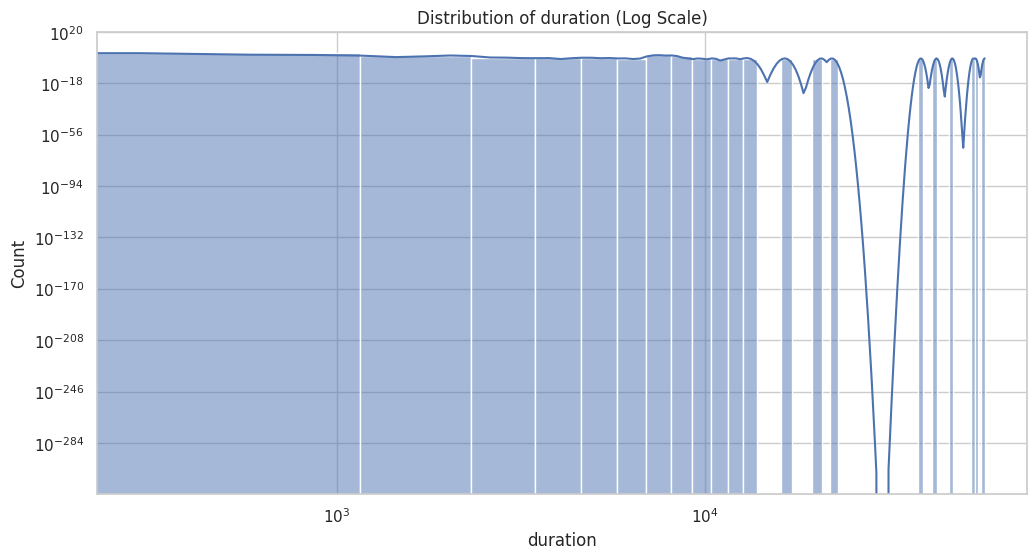

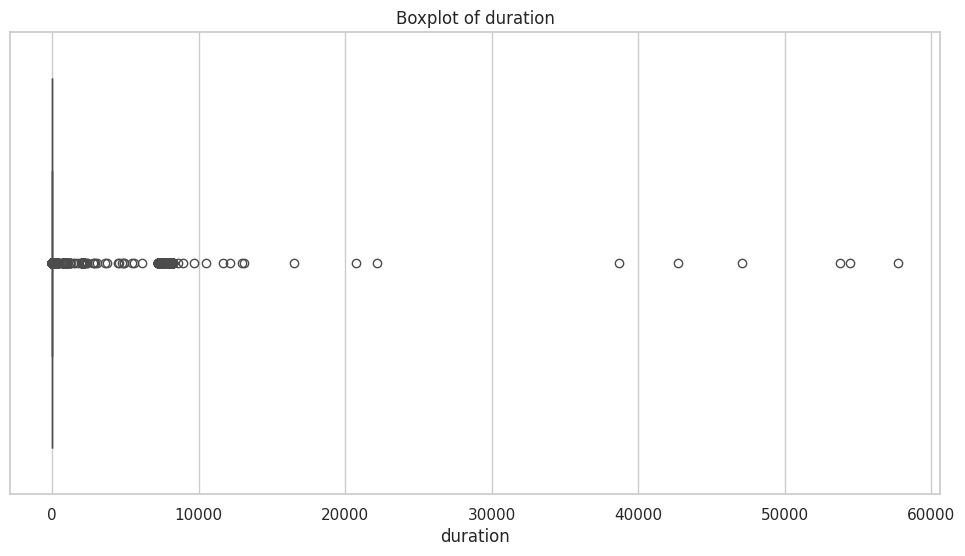

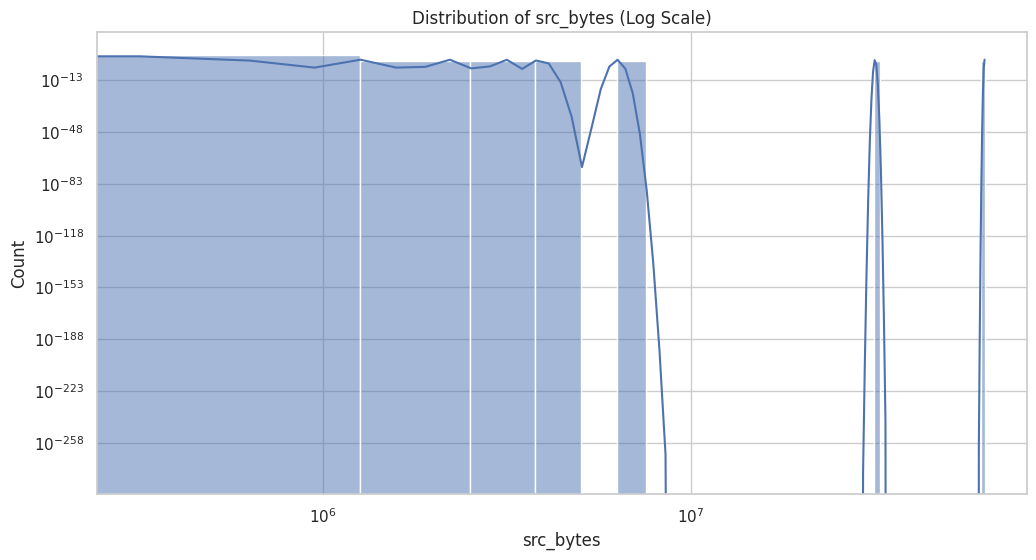

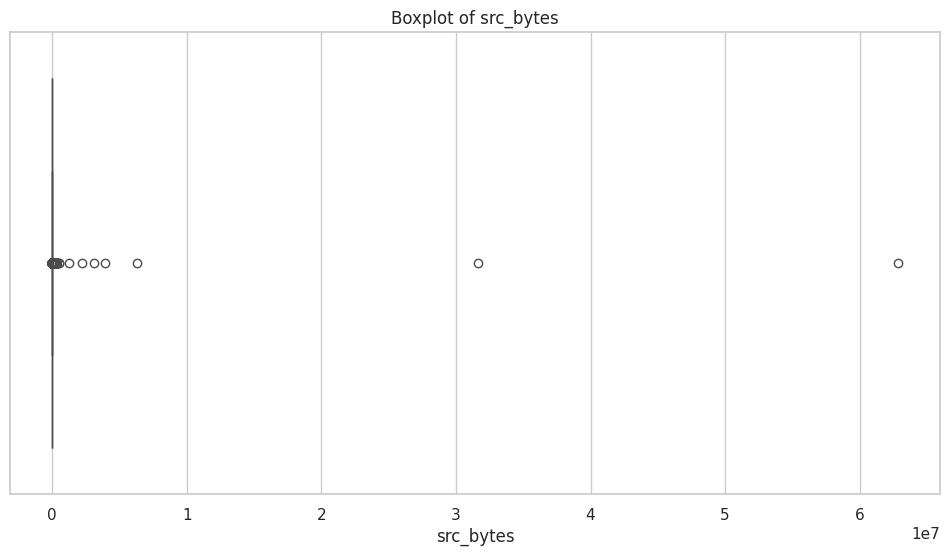

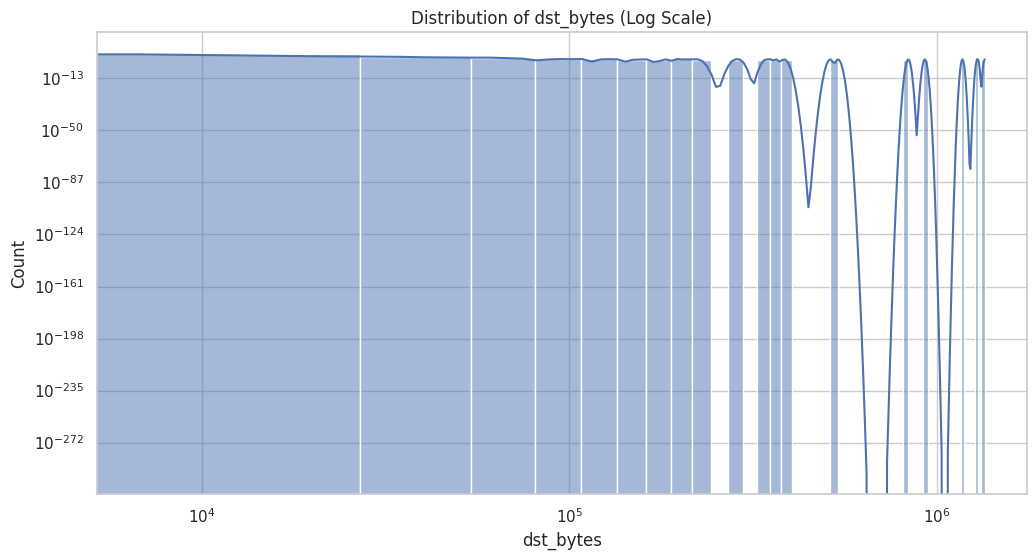

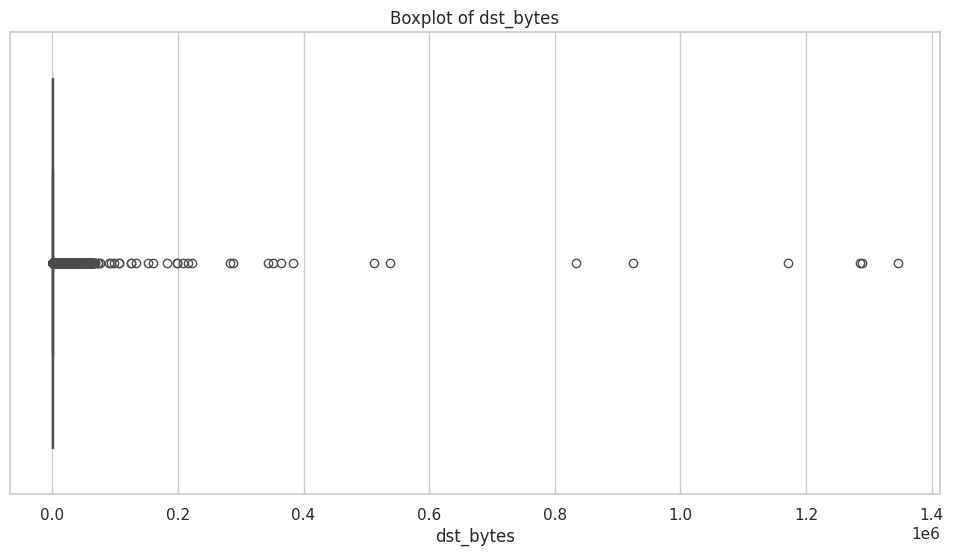

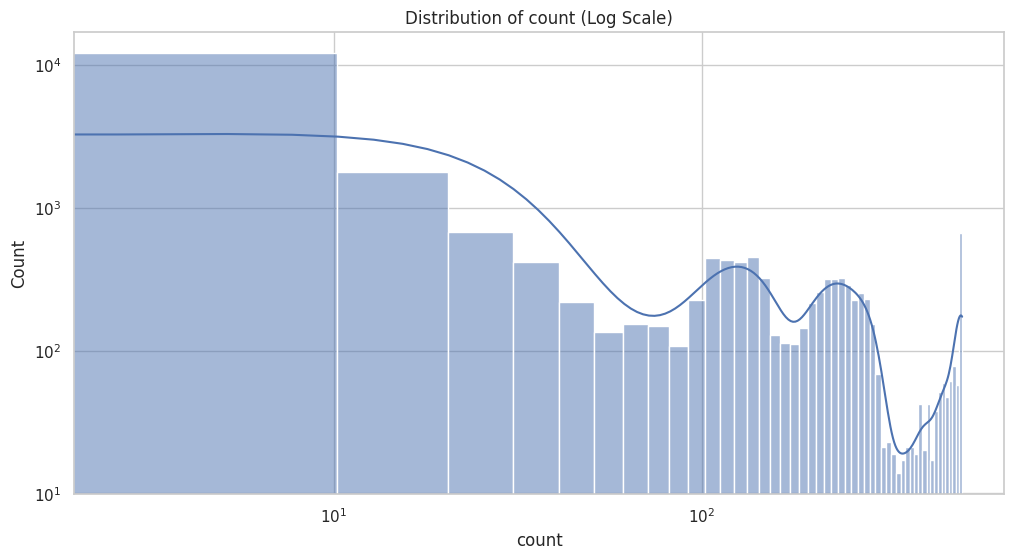

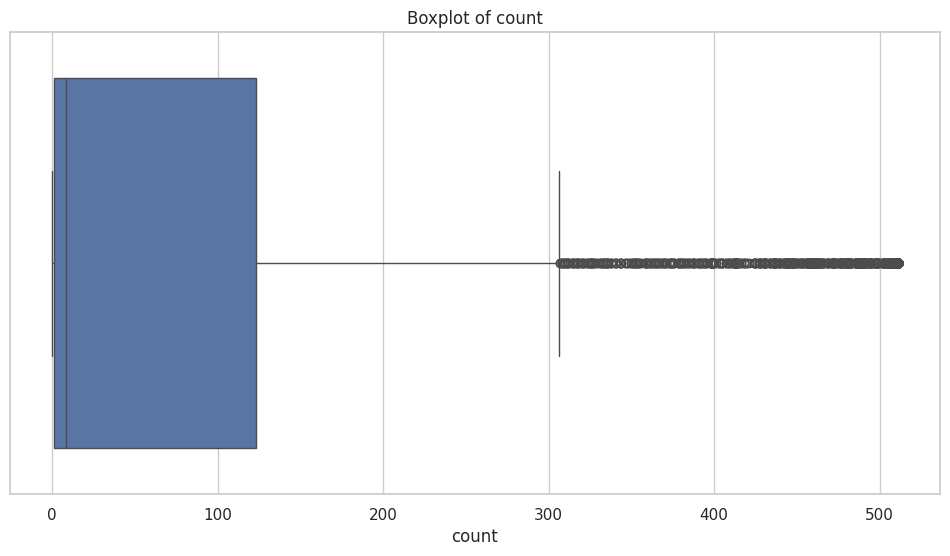

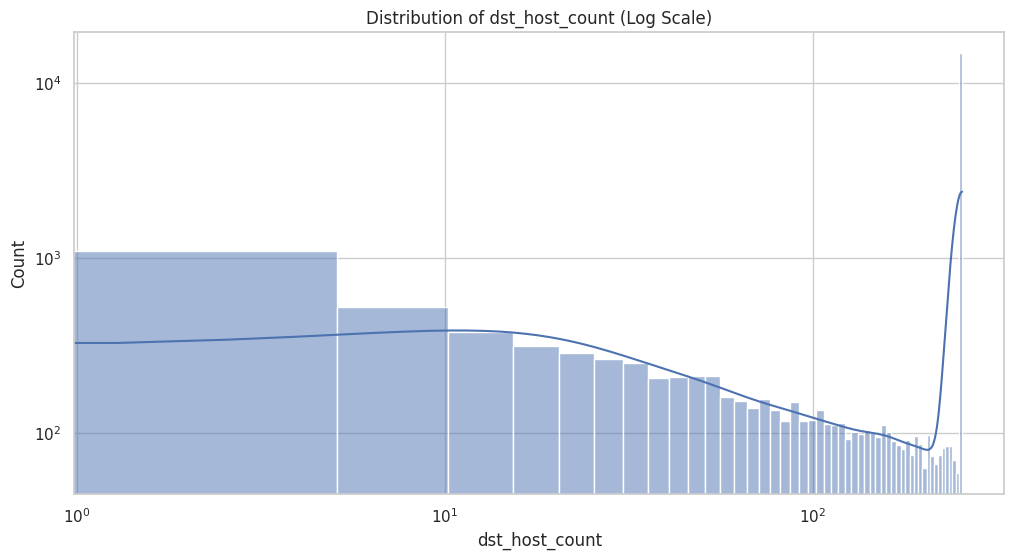

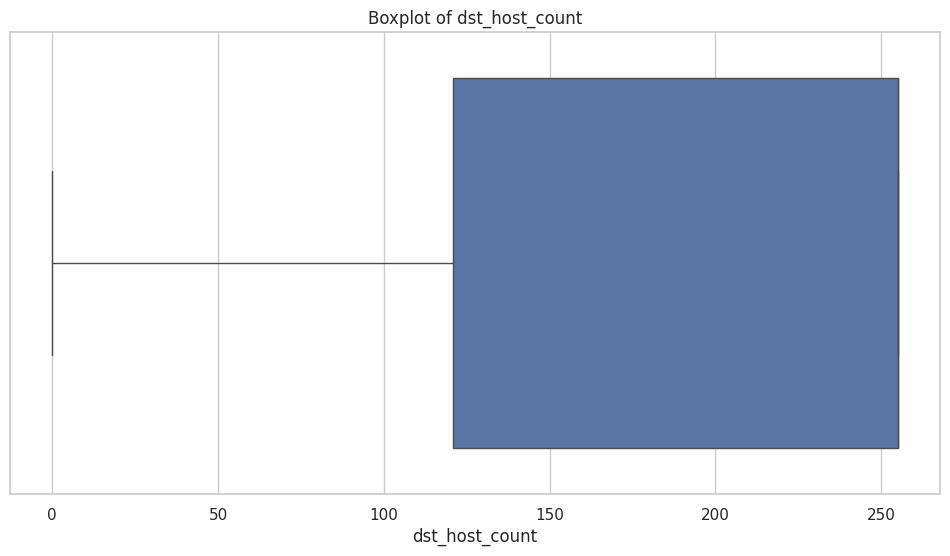

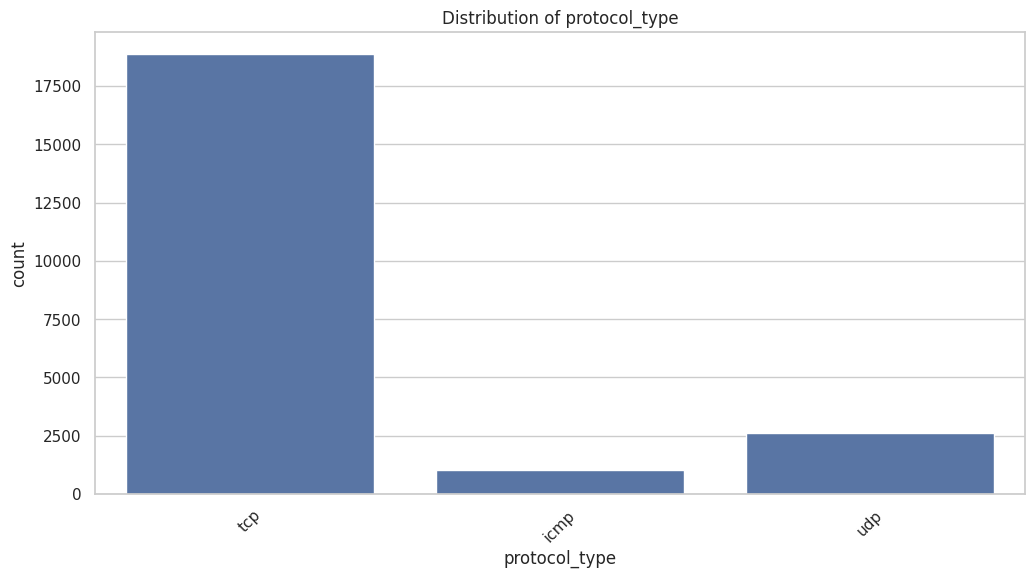

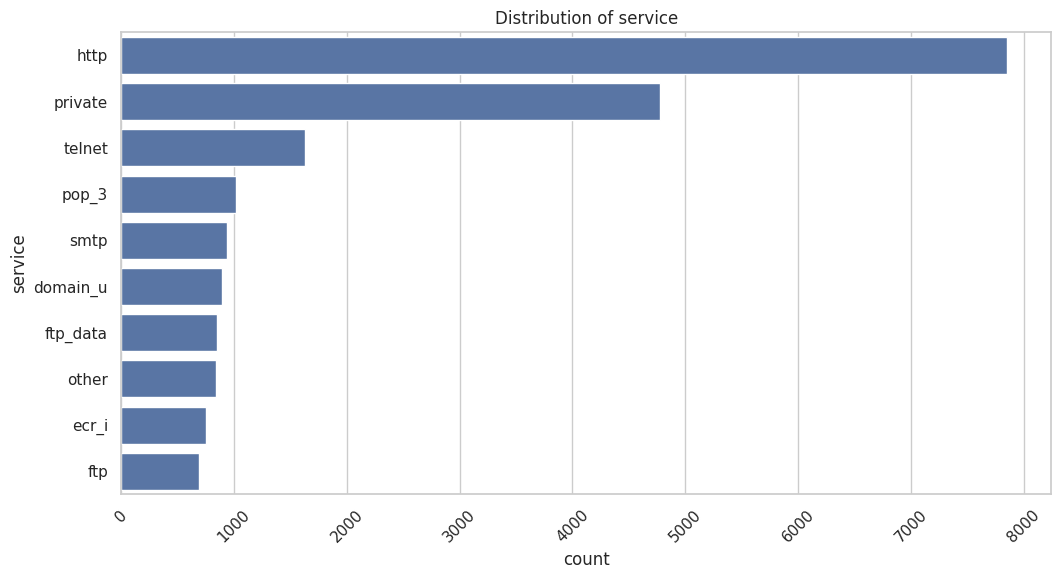

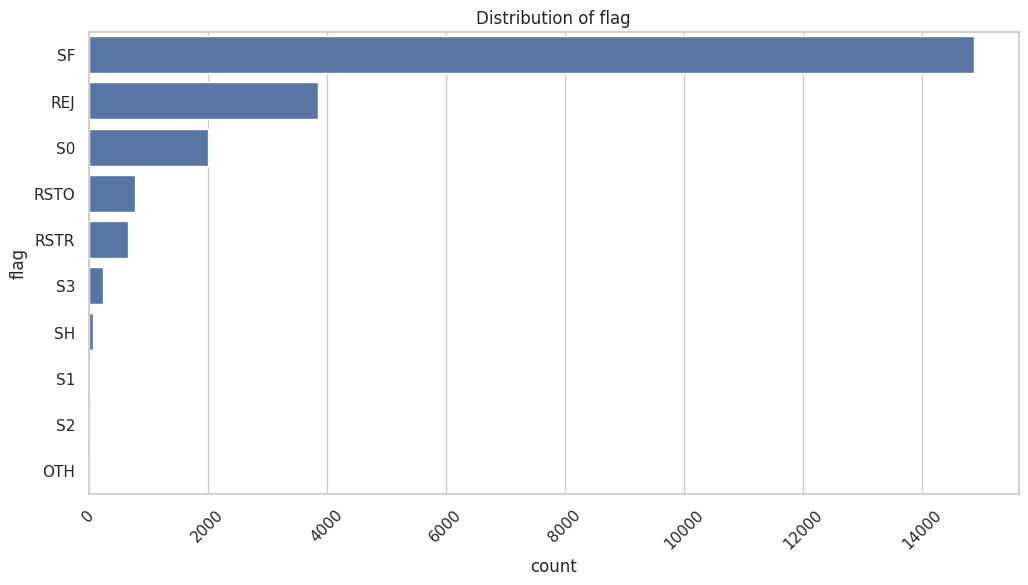

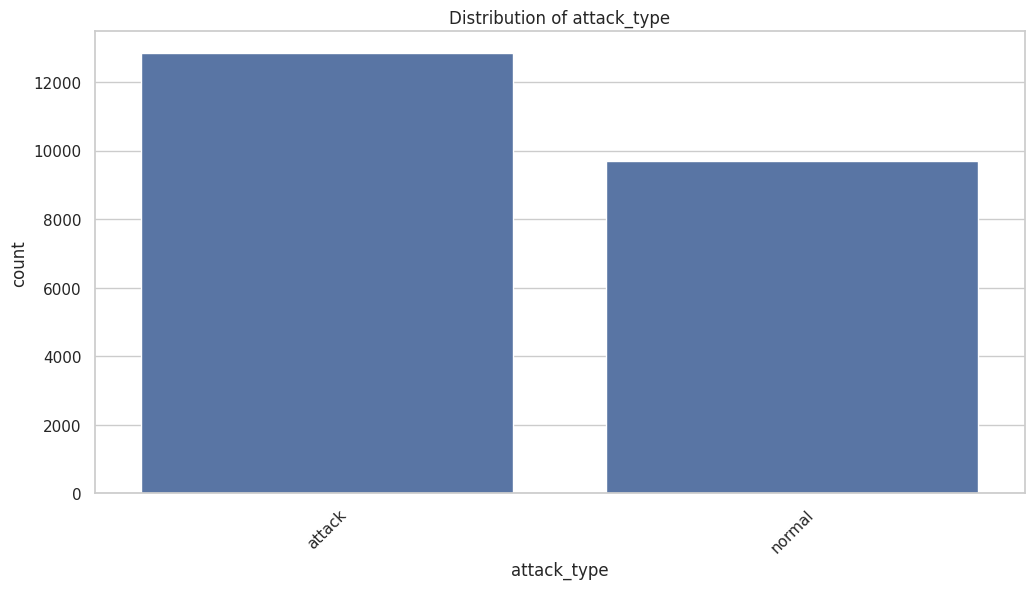

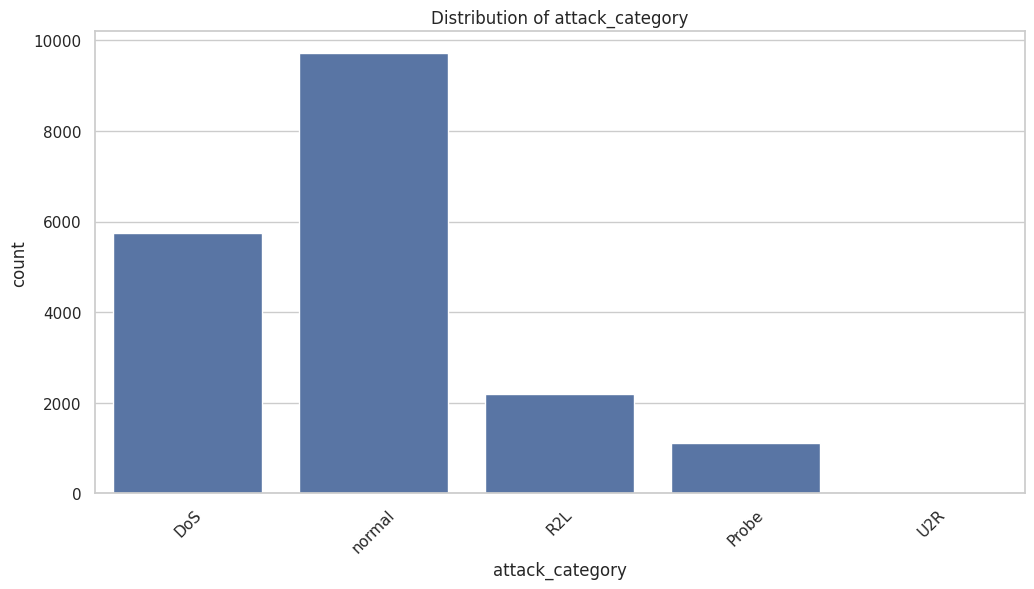

BIVARIATE ANALYSIS


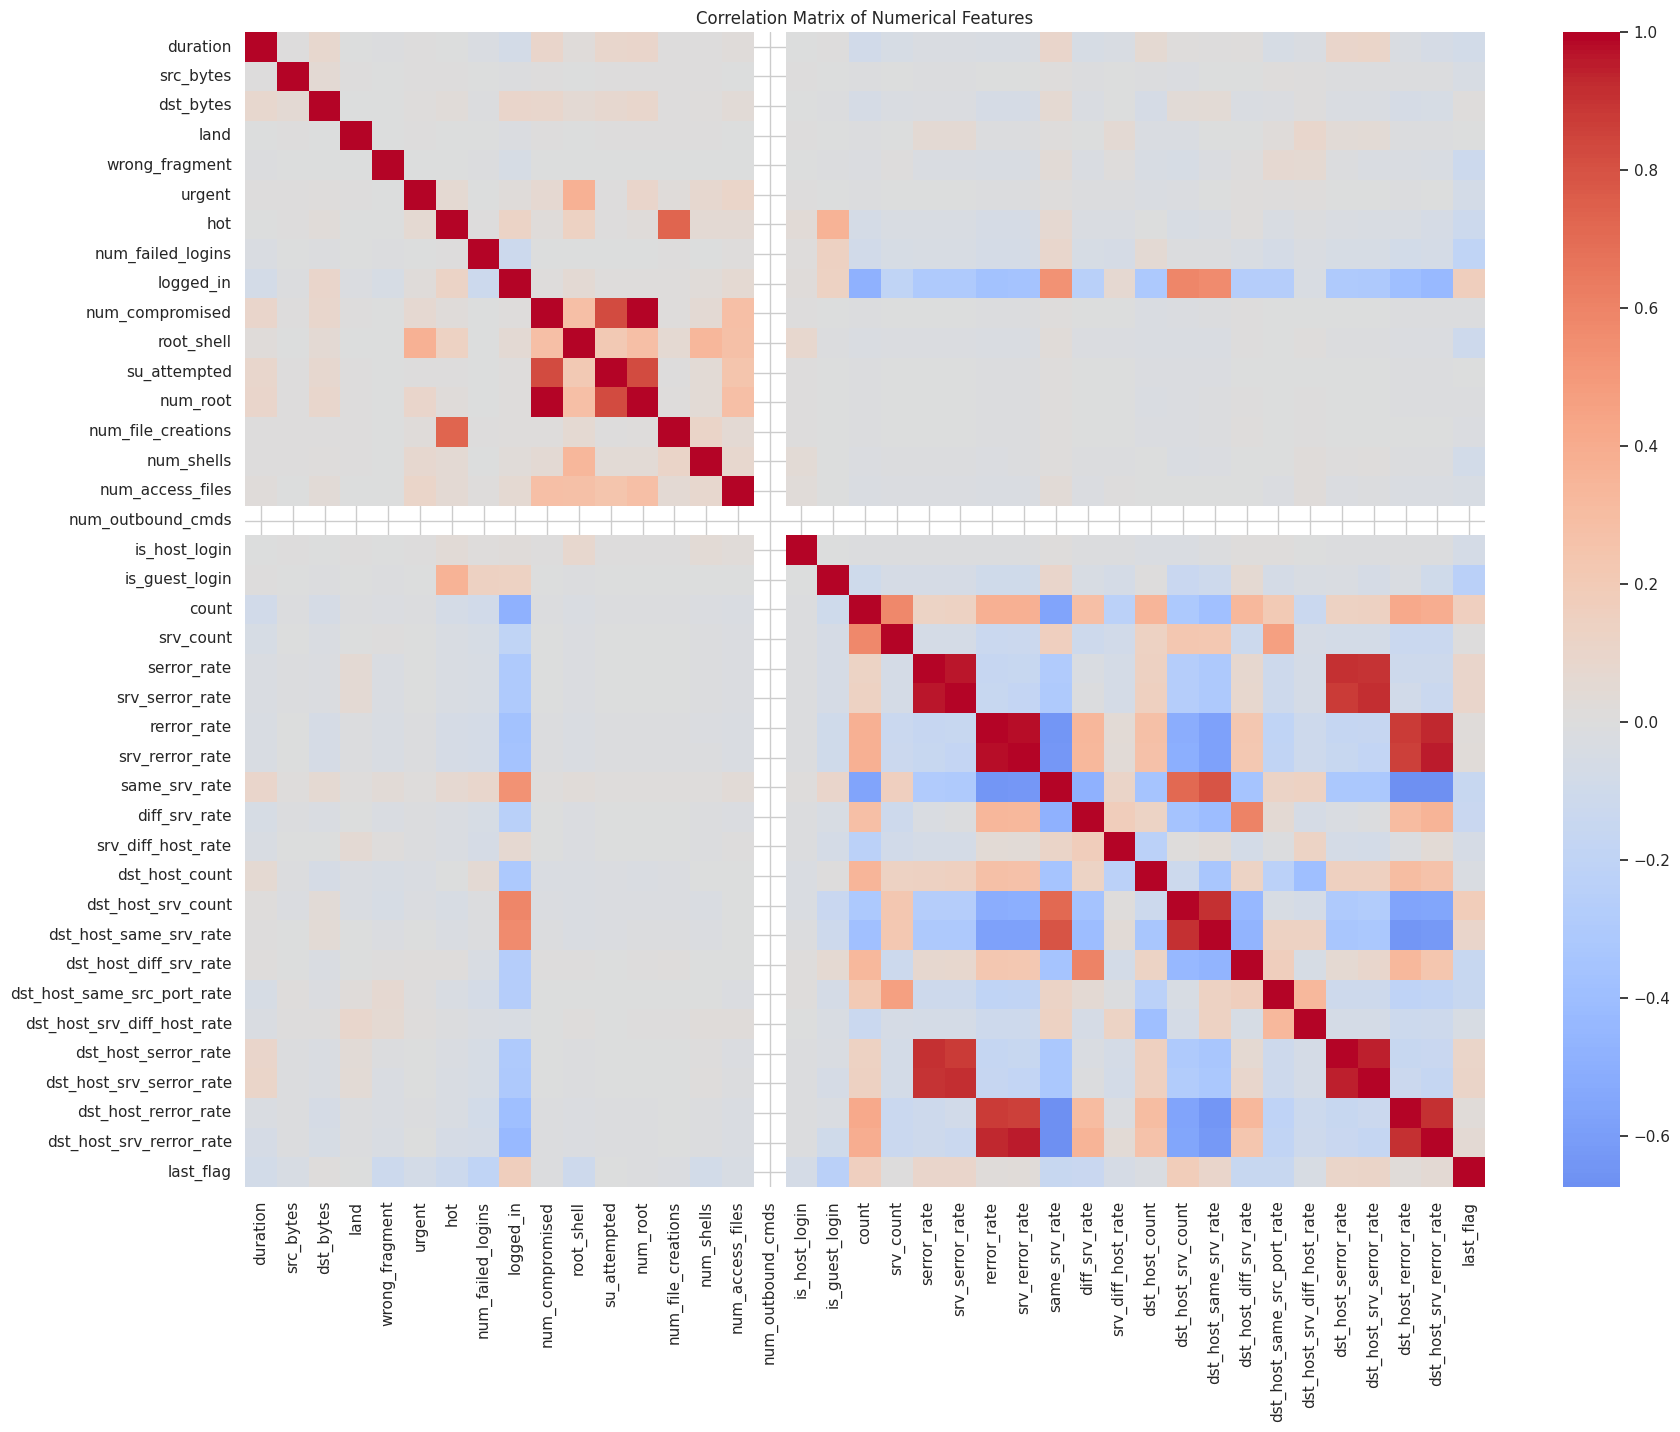


Top Correlated Features:
num_compromised           num_root                    0.995960
num_root                  num_compromised             0.995960
rerror_rate               srv_rerror_rate             0.975535
srv_rerror_rate           rerror_rate                 0.975535
srv_serror_rate           serror_rate                 0.966375
serror_rate               srv_serror_rate             0.966375
srv_rerror_rate           dst_host_srv_rerror_rate    0.947849
dst_host_srv_rerror_rate  srv_rerror_rate             0.947849
dst_host_srv_serror_rate  dst_host_serror_rate        0.945016
dst_host_serror_rate      dst_host_srv_serror_rate    0.945016
dtype: float64


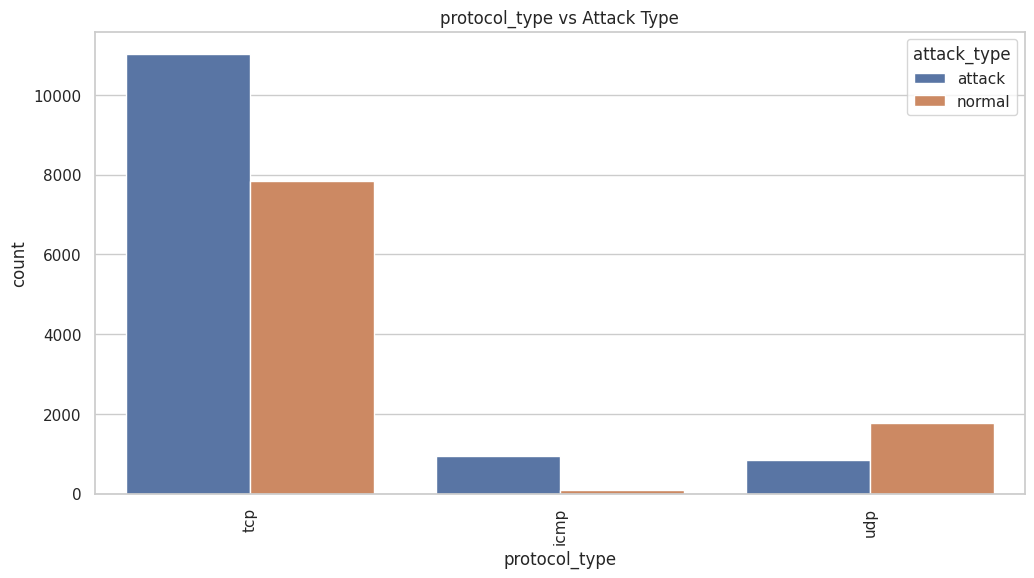

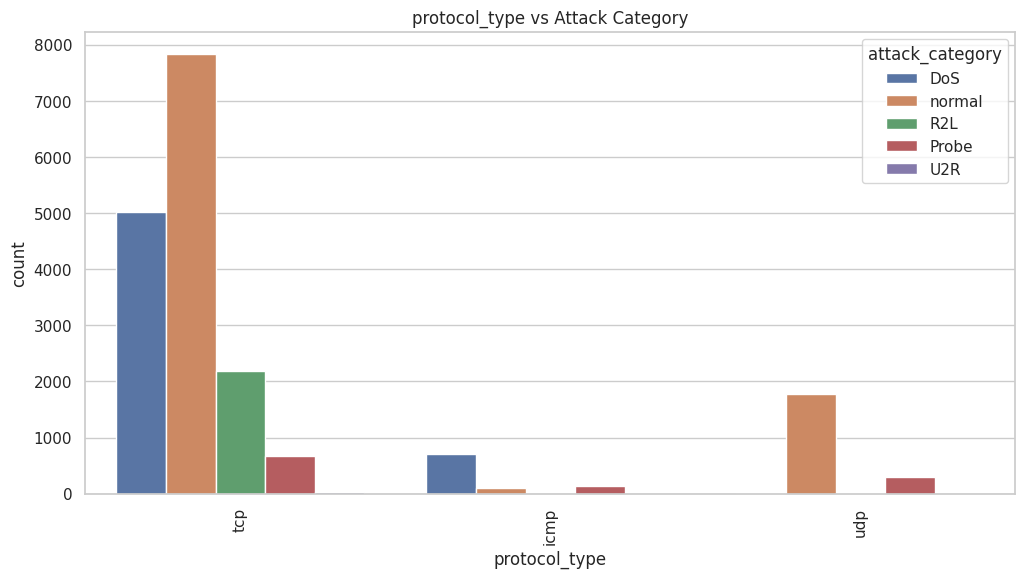

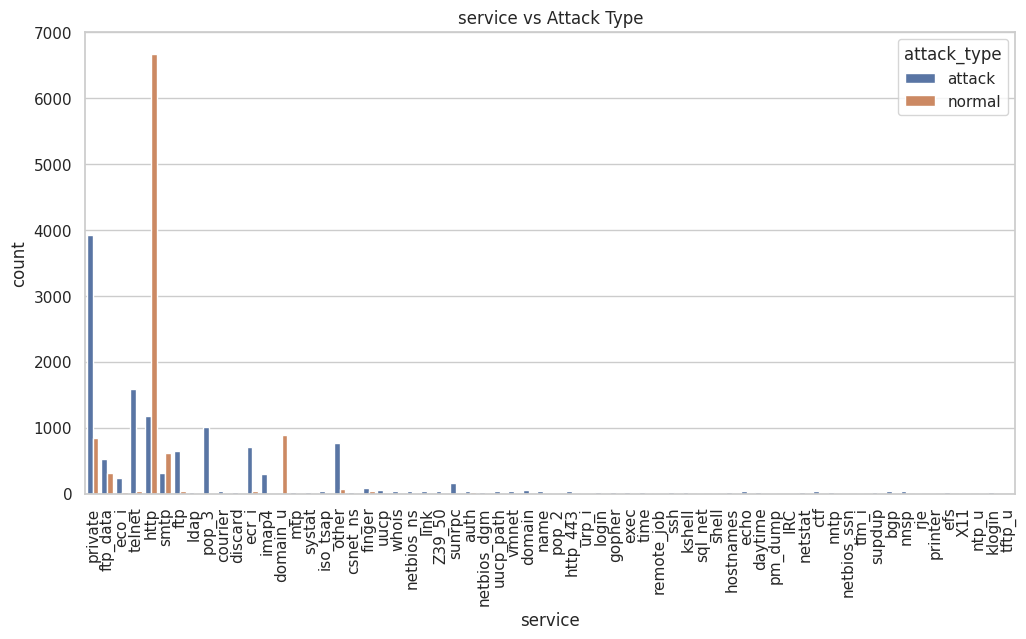

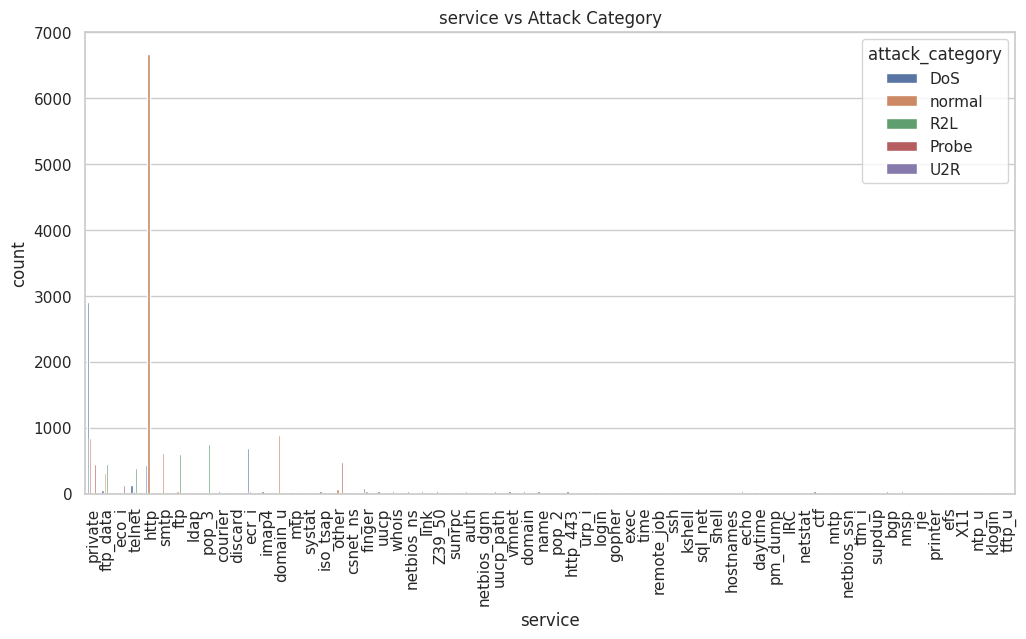

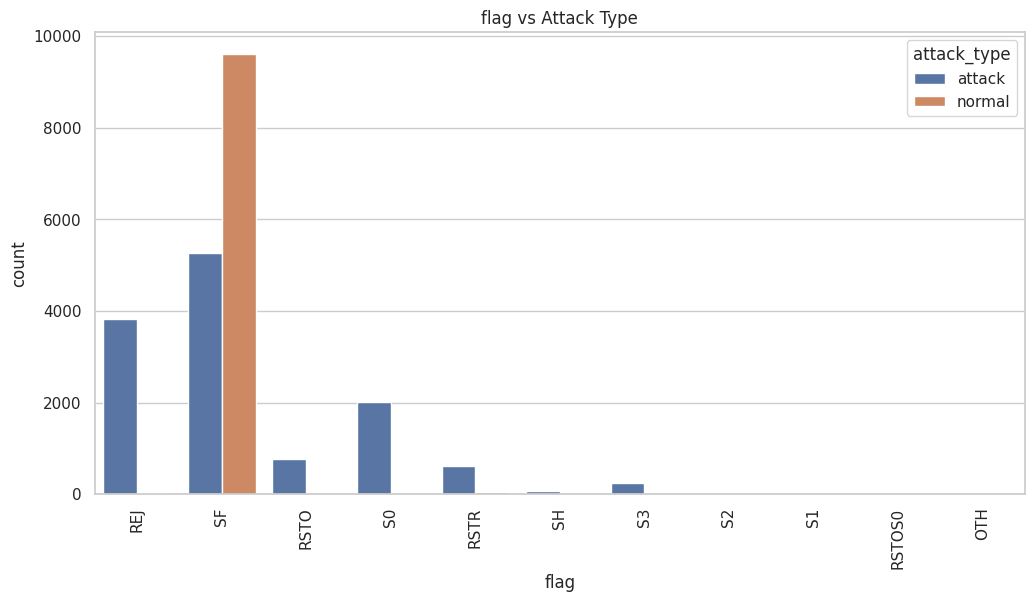

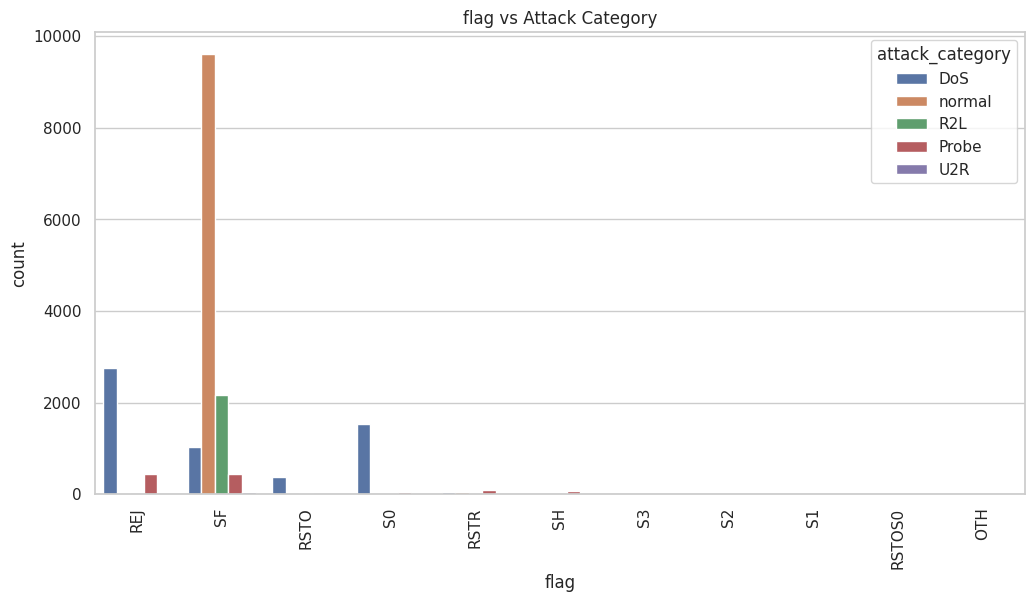


ANOVA Test Results (Numerical Features vs Attack Category):
duration: F-value = 6.45, p-value = 0.0000
src_bytes: F-value = 71.54, p-value = 0.0000
dst_bytes: F-value = 34.13, p-value = 0.0000
count: F-value = 2462.61, p-value = 0.0000
wrong_fragment: F-value = 4.39, p-value = 0.0015
ADVANCED STATISTICAL ANALYSIS

Normality Tests (Shapiro-Wilk):
duration: Statistics=0.124, p-value=0.000
src_bytes: Statistics=0.009, p-value=0.000
dst_bytes: Statistics=0.110, p-value=0.000
count: Statistics=0.655, p-value=0.000

Chi-square Tests for Categorical Features:
protocol_type vs attack_type: Chi2=1165.90, p-value=0.0000
service vs attack_type: Chi2=12765.71, p-value=0.0000
flag vs attack_type: Chi2=8300.69, p-value=0.0000

Effect Size Analysis (Cohen's d):
duration: Cohen's d = 0.219
src_bytes: Cohen's d = 0.031
dst_bytes: Cohen's d = -0.164
count: Cohen's d = 0.603


In [ ]:
def main():
    # Load the dataset (replace with your actual file path)
    filepath = 'kddcup.data_10_percent'  # Using the 10% subset for demonstration
    df = load_and_preprocess_data("/content/Test.txt")

    # Perform statistical analysis
    descriptive_statistics(df)
    univariate_analysis(df)
    bivariate_analysis(df)
    advanced_statistical_analysis(df)

    # Save results if needed
    save_plots_and_results()

if __name__ == "__main__":
    main()